# There are a *lot* of sub-functions that go into the DNN for $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ --- Are they all correct?

## (1): Initializing Requisite Code/Settings:

### (1.1): Import Libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import gepard as g
from gepard.fits import th_KM15

from bkm10_lib.core import DifferentialCrossSection
from bkm10_lib.inputs import BKM10Inputs
from bkm10_lib.cff_inputs import CFFInputs

### (1.2): Matplotlib Plotting Aesthetics:

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True

### (1.3): TensorFlow Configurations:

In [3]:
_FLOATX = tf.float64

# below did NOT work for fixing the stupid tf type mismatch
# tf.keras.mixed_precision.set_global_policy('float32')

print(tf.config.list_physical_devices())
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print(tf.test.gpu_device_name())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Num GPUs Available:  0
Num CPUs Available:  1



### (2.1): Defining the Azimuthal Range:

In [4]:
STARTING_PHI_VALUE_IN_DEGREES = 0
ENDING_PHI_VALUE_IN_DEGREES = 360
NUMBER_OF_PHI_POINTS = 360

phi_array_in_degrees = np.linspace(
    start = STARTING_PHI_VALUE_IN_DEGREES,
    stop = ENDING_PHI_VALUE_IN_DEGREES,
    num = NUMBER_OF_PHI_POINTS)

phi_array_in_radians = np.array([np.radians(degree_value) for degree_value in phi_array_in_degrees])

print(f"We have constructed a Python list of length {len(phi_array_in_radians)} of azimuthal angles from {STARTING_PHI_VALUE_IN_DEGREES} degrees to {ENDING_PHI_VALUE_IN_DEGREES} degrees.")

We have constructed a Python list of length 360 of azimuthal angles from 0 degrees to 360 degrees.


### (2.2): Defining the Kinematic Point:

#### (2.2.1): Required Kinematics

In [5]:
TEST_BEAM_ENERGY = 5.75
TEST_QSQ = 1.82
TEST_XB = 0.34
TEST_T = -.17

# these values come later *and* are derived from the values above:
# see [this Mathematica notebook](https://github.com/Woofmagic/BKM10_Spin_Polarized/blob/main/mathematica/bkm10_test.nb)
TEST_EP = 0.47293561004973345
TEST_Y = 0.49609612355928445
TEST_XI = 0.19906188837146524
TEST_T_MIN = -0.13551824472915253
TEST_T_PRIME = -0.034481755270847486
TEST_K_TILDE = 0.1592415651944438
TEST_K = 0.08492693191323883
TEST_FE = 0.6511853266961825
TEST_FG = 1.8186612105254523
TEST_F2 = 1.1137103937669304
TEST_F1 = 0.7049508167585219
TEST_KDD = (
    (-1.*TEST_QSQ / (2.*TEST_Y*(1.+TEST_EP**2))) * 
    (1. + ((2.*TEST_K*np.cos(tf.constant(np.pi) - phi_array_in_radians)) - ((TEST_T / TEST_QSQ)*(1.-(TEST_XB * (2. - TEST_Y)) + (TEST_Y * TEST_EP**2 / 2.))) + (TEST_Y * TEST_EP**2 / 2.))))

TEST_P1 = (1. + (2. * (TEST_KDD / TEST_QSQ)))
TEST_P2 = ((-2. * (TEST_KDD / TEST_QSQ)) + (TEST_T / TEST_QSQ))

#### (2.2.2): Required CFF Values

[NOTE]: The "XDJ CFFs" come from the paper we cited earlier: [Higher-order kinematical effects in deeply virtual Compton scattering](https://link.springer.com/article/10.1007/JHEP12(2021)103).

In [6]:
# these are test values ONLY! (i.e. not KM15 values)
CFF_REAL_H_XDJ = -0.897
CFF_REAL_HT_XDJ = 2.444
CFF_REAL_E_XDJ = -0.541
CFF_REAL_ET_XDJ = 2.207 
CFF_IMAG_H_XDJ = 2.421
CFF_IMAG_HT_XDJ = 1.131
CFF_IMAG_E_XDJ = 0.903
CFF_IMAG_ET_XDJ = 5.383

### (2.3): Use the KM15 Model of $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ to Generate a True Value:

Uses `gepard`'s `DataPoint()` class to define the kinematic setting.

In [7]:
test_datapoints = [g.DataPoint(
    xB = TEST_XB, t = TEST_T, Q2 = TEST_QSQ, phi = fixed_phi,
    process = "ep2epgamma", exptype = 'fixed target',
    in1energy = TEST_BEAM_ENERGY, in1charge = -1, in1polarization = +1,
    observable = 'XS',
    fname = 'Trento') for fixed_phi in phi_array_in_radians]

#### (2.3.1): Check out the Length of the Datapoint Array:

These arrays should have exactly the same length without absolutely any difference.

In [8]:
len(test_datapoints) == len(phi_array_in_radians)

True

### (2.4): Evaluate $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ using KM15 for the Datapoints 

In [9]:
# cff H
real_h_values = [th_KM15.ReH(datapoint) for datapoint in test_datapoints]
imag_h_values = [th_KM15.ImH(datapoint) for datapoint in test_datapoints]

# cff E
real_e_values = [th_KM15.ReE(datapoint) for datapoint in test_datapoints]
imag_e_values = [th_KM15.ImE(datapoint) for datapoint in test_datapoints]

# cff Ht
real_ht_values = [th_KM15.ReHt(datapoint) for datapoint in test_datapoints]
imag_ht_values = [th_KM15.ImHt(datapoint) for datapoint in test_datapoints]

# cff Et
real_et_values = [th_KM15.ReEt(datapoint) for datapoint in test_datapoints]
imag_et_values = [th_KM15.ImEt(datapoint) for datapoint in test_datapoints]

#### (2.4.1): Check out the Length of the CFF Data Array:

These arrays should ALSO be of exactly the same length --- For every phi, we have a kinematic point, and every kinematic point will have a CFF value.

In [10]:
print(len(real_h_values) == len(test_datapoints))
print(len(imag_h_values) == len(test_datapoints))

True
True


### (2.5): Use the [BKM10 Library](https://pypi.org/project/bkm10/) to Predict the Cross-Section

#### (2.5.1): Define the CFF Values --- **Very Important!!**

Note that at the specific kinematic settings of
```python
TEST_BEAM_ENERGY = 5.75
TEST_QSQ = 1.82
TEST_XB = 0.34
TEST_T = -.17
```
one can use the following configuration of the 8 CFFs according to [Higher-order kinematical effects in deeply virtual Compton scattering](https://link.springer.com/article/10.1007/JHEP12(2021)103) --- See Table 1
```python
CFF_H_KM15 = complex(-0.897, 2.421)
CFF_H_TILDE_KM15 = complex(2.444, 1.131)
CFF_E_KM15 = complex(-0.541, 0.903)
CFF_E_TILDE_KM15 = complex(2.207, 5.383)
```

So, **please understand** that what we will do is **change only the `CFF_H_KM15` values** in accordance with what the KM15 model predicts and leave **all the other CFFs the same**!

In [11]:
# we slice at [0] because, as we verified earlier, these arrays are all the same value; equivalence class defined on them

print(f"Now setting Re[H] = {real_h_values[0]}")
print(f"Now setting Im[H] = {imag_h_values[0]}")

print(f"Now setting Re[H] = {real_e_values[0]}")
print(f"Now setting Im[E] = {imag_e_values[0]}")

print(f"Now setting Re[Ht] = {real_ht_values[0]}")
print(f"Now setting Im[Ht] = {imag_ht_values[0]}")

print(f"Now setting Re[Et] = {real_et_values[0]}")
print(f"Now setting Im[Et] = {imag_et_values[0]}")

CFF_REAL_H_KM15 = real_h_values[0]
CFF_IMAG_H_KM15 = imag_h_values[0]
CFF_REAL_E_KM15 = real_e_values[0]
CFF_IMAG_E_KM15 = imag_e_values[0]
CFF_REAL_HT_KM15 = real_ht_values[0]
CFF_IMAG_HT_KM15 = imag_ht_values[0]
CFF_REAL_ET_KM15 = real_et_values[0]
CFF_IMAG_ET_KM15 = imag_et_values[0]

CFF_H_KM15 = complex(CFF_REAL_H_KM15, CFF_IMAG_H_KM15)
CFF_H_TILDE_KM15 = complex(CFF_REAL_HT_KM15, CFF_IMAG_HT_KM15)
CFF_E_KM15 = complex(CFF_REAL_E_KM15, CFF_IMAG_E_KM15)
CFF_E_TILDE_KM15 = complex(CFF_REAL_ET_KM15, CFF_IMAG_ET_KM15)

Now setting Re[H] = -2.4490177469911387
Now setting Im[H] = 3.481649173751274
Now setting Re[H] = 2.217354372014208
Now setting Im[E] = 0.0
Now setting Re[Ht] = 1.4093937264544776
Now setting Im[Ht] = 1.5773644025601397
Now setting Re[Et] = 144.4101642020152
Now setting Im[Et] = 0.0


#### (2.5.2): Use the BKM10 Library to Evaluate the Cross-Section as a Function of $\phi$

In [12]:
km15_cross_section = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_QSQ,
            x_Bjorken = TEST_XB,
            squared_hadronic_momentum_transfer_t = TEST_T),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = CFF_H_KM15,
            compton_form_factor_h_tilde = CFF_H_TILDE_KM15,
            compton_form_factor_e = CFF_E_KM15,
            compton_form_factor_e_tilde = CFF_E_TILDE_KM15),
        "using_ww": True
    },
    verbose = False,
    debugging = False)

cross_section_xdj = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_QSQ,
            x_Bjorken = TEST_XB,
            squared_hadronic_momentum_transfer_t = TEST_T),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = complex(CFF_REAL_H_XDJ, CFF_IMAG_H_XDJ),
            compton_form_factor_h_tilde = complex(CFF_REAL_HT_XDJ, CFF_IMAG_HT_XDJ),
            compton_form_factor_e = complex(CFF_REAL_E_XDJ, CFF_IMAG_E_XDJ),
            compton_form_factor_e_tilde = complex(CFF_REAL_ET_XDJ, CFF_IMAG_ET_XDJ)),
        "using_ww": True
    },
    verbose = False,
    debugging = False)

cross_section_xdj_int_only = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_QSQ,
            x_Bjorken = TEST_XB,
            squared_hadronic_momentum_transfer_t = TEST_T),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = complex(CFF_REAL_H_XDJ, CFF_IMAG_H_XDJ),
            compton_form_factor_h_tilde = complex(CFF_REAL_HT_XDJ, CFF_IMAG_HT_XDJ),
            compton_form_factor_e = complex(CFF_REAL_E_XDJ, CFF_IMAG_E_XDJ),
            compton_form_factor_e_tilde = complex(CFF_REAL_ET_XDJ, CFF_IMAG_ET_XDJ)),
        "using_ww": True
    },
    bh_setting = False,
    dvcs_setting = False,
    interference_setting = True,
    verbose = False,
    debugging = False)

##### (2.5.2.1): $d^{4}\sigma^{UU}$ and $\text{BSA}$ Values using both **KM15** and **XDJ** CFFs:

In [13]:
bkm10_cross_sections_km15 = km15_cross_section.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = 0.0,
    target_polarization = 0.0).real

bkm10_cross_sections_xdj = cross_section_xdj.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = 0.0,
    target_polarization = 0.0).real

##### (2.5.2.2): $d^{4}\sigma^{+U}$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [14]:
bkm10_plus_beam_cross_sections_km15 = km15_cross_section.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = +1.0,
    target_polarization = 0.0).real

bkm10_plus_beam_cross_sections_xdj = cross_section_xdj.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = +1.0,
    target_polarization = 0.0).real

##### (2.5.2.3): $d^{4}\sigma^{-U}$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [15]:
bkm10_minus_beam_cross_sections_km15 = km15_cross_section.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = -1.0,
    target_polarization = 0.0).real

bkm10_minus_beam_cross_sections_xdj = cross_section_xdj.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = -1.0,
    target_polarization = 0.0).real

##### (2.5.2.4): $d^{4}\sigma^{UL}$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [16]:
bkm10_lp_cross_sections_km15 = km15_cross_section.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = 0.0,
    target_polarization = +0.5).real

bkm10_lp_cross_sections_xdj = cross_section_xdj.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = 0.0,
    target_polarization = +0.5).real


##### (2.5.2.5): $d^{4}\sigma^{+L}$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [17]:
bkm10_plus_beam_lp_cross_sections_km15 = km15_cross_section.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = +1.0,
    target_polarization = +0.5).real

bkm10_plus_beam_lp_cross_sections_xdj = cross_section_xdj.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = +1.0,
    target_polarization = +0.5).real

##### (2.5.2.6): $d^{4}\sigma^{-L}$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [18]:
bkm10_minus_beam_lp_cross_sections_km15 = km15_cross_section.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = -1.0,
    target_polarization = +0.5).real

bkm10_minus_beam_lp_cross_sections_xdj = cross_section_xdj.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = -1.0,
    target_polarization = +0.5).real

##### (2.5.2.7): $\text{BSA}\left( \Lambda = 0 \right)$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [19]:
bkm10_bsa_km15 = km15_cross_section.compute_bsa(
    phi_array_in_radians, 
    target_polarization = 0.0).real

bkm10_bsa_xdj = cross_section_xdj.compute_bsa(
    phi_array_in_radians, 
    target_polarization = 0.0).real

##### (2.5.2.8): $\text{BSA}\left( \Lambda = +1/2 \right)$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [20]:
bkm10_plus_lp_bsa_km15 = km15_cross_section.compute_bsa(
    phi_array_in_radians,
    target_polarization = +0.5).real

bkm10_plus_lp_bsa_xdj = cross_section_xdj.compute_bsa(
    phi_array_in_radians,
    target_polarization = +0.5).real

##### (2.5.2.9): $\text{BSA}\left( \Lambda = -1/2 \right)$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [21]:
bkm10_minus_lp_bsa_km15 = km15_cross_section.compute_bsa(
    phi_array_in_radians,
    target_polarization = -0.5).real

bkm10_minus_lp_bsa_xdj = cross_section_xdj.compute_bsa(
    phi_array_in_radians,
    target_polarization = -0.5).real

##### (2.5.2.10): $\text{TSA}\left( \lambda = 0.0 \right)$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [22]:
bkm10_tsa_km15 = km15_cross_section.compute_tsa(
    phi_array_in_radians,
    lepton_polarization = 0.0).real

bkm10_tsa_xdj = cross_section_xdj.compute_tsa(
    phi_array_in_radians,
    lepton_polarization = 0.0).real

##### (2.5.2.11): $\text{TSA}\left( \lambda = +1 \right)$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [23]:
bkm10_plus_beam_tsa_km15 = km15_cross_section.compute_tsa(
    phi_array_in_radians,
    lepton_polarization = +1.0).real

bkm10_plus_beam_tsa_xdj = cross_section_xdj.compute_tsa(
    phi_array_in_radians,
    lepton_polarization = +1.0).real

##### (2.5.2.12): $\text{TSA}\left( \lambda = -1 \right)$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [24]:
bkm10_minus_beam_tsa_km15 = km15_cross_section.compute_tsa(
    phi_array_in_radians,
    lepton_polarization = -1.0).real

bkm10_minus_beam_tsa_xdj = cross_section_xdj.compute_tsa(
    phi_array_in_radians,
    lepton_polarization = -1.0).real

##### (2.5.2.13): $\text{DSA}$ Cross-Section Values using both **KM15** and **XDJ** CFFs:

In [25]:
bkm10_dsa_km15 = km15_cross_section.compute_dsa(
    phi_array_in_radians).real

bkm10_dsa_xdj = cross_section_xdj.compute_dsa(
    phi_array_in_radians).real

### (2.6): Create Strings for Plotting:

In [26]:
title_string = (
    rf"$Q^2 = {TEST_QSQ:.2f}$ GeV$^2$, "
    rf"$x_B = {TEST_XB:.2f}$, "
    rf"$t = {TEST_T:.2f}$ ,"
    rf"$k = {TEST_BEAM_ENERGY:.2f}$ GeV"
)

km15_cff_string = (
    rf"$\mathcal{{H}} = {CFF_H_KM15:.3f}$, "
    rf"$\mathcal{{E}} = {CFF_E_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{H}}}} = {CFF_H_TILDE_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{E}}}} = {CFF_E_TILDE_KM15:.3f}$ "
)

xdj_cff_string = (
    rf"$\mathcal{{H}} = {complex(CFF_REAL_H_XDJ, CFF_IMAG_H_XDJ):.3f}$, "
    rf"$\mathcal{{E}} = {complex(CFF_REAL_E_XDJ, CFF_IMAG_E_XDJ):.3f}$, "
    rf"$\widetilde{{\mathcal{{H}}}} = {complex(CFF_REAL_HT_XDJ, CFF_IMAG_HT_XDJ):.3f}$, "
    rf"$\widetilde{{\mathcal{{E}}}} = {complex(CFF_REAL_ET_XDJ, CFF_IMAG_ET_XDJ):.3f}$ "
)

## (3): DNN Model/Function Definitions:

### (3.1): Static Quantities Used in Loss Computation:

[NOTE]: The `dtype` of these constants can change if things run or not.

```
InvalidArgumentError: cannot compute Mul as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:Mul] name:
```

In [27]:
_CONVERSION_FACTOR = .389379 * 1000000.
_MASS_OF_PROTON_IN_GEV = 0.93827208816
_QED_FINE_STRUCTURE = 1./137.035999177
_ELECTRIC_FORM_FACTOR_CONSTANT = 0.710649
_PROTON_MAGNETIC_MOMENT = 2.79284734463

# _CONVERSION_FACTOR = tf.constant(.389379 * 1000000.)
# _MASS_OF_PROTON_IN_GEV = tf.constant(0.93827208816)
# _QED_FINE_STRUCTURE = tf.constant(1./137.035999177)
# _ELECTRIC_FORM_FACTOR_CONSTANT = tf.constant(0.710649)
# _PROTON_MAGNETIC_MOMENT = tf.constant(2.79284734463)

# _CONVERSION_FACTOR = tf.constant(.389379 * 1000000., dtype = _FLOATX)
# _MASS_OF_PROTON_IN_GEV = tf.constant(0.93827208816, dtype = _FLOATX)
# _QED_FINE_STRUCTURE = tf.constant(1./137.035999177, dtype = _FLOATX)
# _ELECTRIC_FORM_FACTOR_CONSTANT = tf.constant(0.710649, dtype = _FLOATX)
# _PROTON_MAGNETIC_MOMENT = tf.constant(2.79284734463, dtype = _FLOATX)

### (3.2): Relevant Functions in Loss Computation:

#### (3.2.1): Kinematic Quantities:

In [28]:
def compute_fe(t):
    return 1./ (1. - (t / _ELECTRIC_FORM_FACTOR_CONSTANT))**2

def compute_fg(fe):
    return _PROTON_MAGNETIC_MOMENT * fe

def compute_f2(t, fe, fg):
    tau = -1. * t/ (4. * _MASS_OF_PROTON_IN_GEV**2)
    numerator = fg - fe
    denominator = 1. + tau
    return numerator / denominator

def compute_f1(fg, f2):
    return fg - f2

def compute_epsilon(xb, q_squared):
    return 2. * xb * _MASS_OF_PROTON_IN_GEV / np.sqrt(q_squared)

def compute_y(k_beam, q_squared, ep):
    return np.sqrt(q_squared) / (ep * k_beam)

def compute_skewness(xb, t, q_squared):
    return xb * (1. + (t / (2. * q_squared))) / (2. - xb + (xb * t / q_squared))

def compute_t_min(xb, q_squared, ep):
    return -1. * q_squared * ((2. * (1. - xb) * (1. - np.sqrt(1. + ep**2))) + ep**2) / ((4. * xb * (1. - xb)) + ep**2)

def compute_t_prime(t, tmin):
    return (t-tmin)

def compute_k_tilde(xb, q_squared, t, tmin, ep):
    return np.sqrt(tmin - t) * np.sqrt(((1. - xb) * np.sqrt((1. + ep**2))) + (((tmin - t) * (ep**2 + (4. * (1. - xb) * xb))) / (4. * q_squared)))

def compute_k(q_squared, y_lep, ep, k_tilde):
    return np.sqrt(((1. - y_lep + (ep**2 * y_lep**2 / 4.)) / q_squared)) * k_tilde

def compute_k_dot_delta(q_squared, xb, t, phi_azi, ep, y_lep, k):
    return (-1.*q_squared / (2.*y_lep*(1.+ep**2))) * (1. + ((2.*k*np.cos(tf.constant(np.pi)- phi_azi)) - ((t / q_squared)*(1.-(xb * (2. - y_lep)) + (y_lep * ep**2 / 2.))) + (y_lep * ep**2 / 2.)))

def prop_1(q_squared, kdd):
    return (1. + (2. * (kdd / q_squared)))

def prop_2(q_squared, t, kdd):
    return ((-2. * (kdd / q_squared)) + (t / q_squared))

#### (3.2.2): BH Coefficients:

In [29]:
def bh_unp_c0(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float):
    first_line = 8. * k**2 * (((2. + 3. * ep**2) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) / (t / q_sq)) + (2. * xb**2 * (f1 + f2)**2))
    second_line_first_part = (2. + ep**2) * ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) * (1. + (t / q_sq))**2 + 4. * (1 - xb) * (1. + (xb * (t / q_sq)))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2)))
    second_line_second_part = 4. * xb**2 * (xb + (1. - xb + (ep**2 / 2.)) * (1 - (t / q_sq))**2 - xb * (1. - 2. * xb) * (t / q_sq)**2) * (f1 + f2)**2
    second_line = (2. - y)**2 * (second_line_first_part + second_line_second_part)
    third_line = 8. * (1. + ep**2) * (1. - y - (ep**2 * y**2 / 4.)) * (2. * ep**2 * (1 - (t / (4. * _MASS_OF_PROTON_IN_GEV**2))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) - xb**2 * (1 - (t / q_sq))**2 * (f1 + f2)**2)
    c0_unpolarized_bh = first_line + second_line + third_line
    return c0_unpolarized_bh

def bh_unp_c1(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t / (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_line_first_part = ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) - 2. * xb - ep**2) * weighted_combination_of_form_factors
    first_line_second_part = 2. * xb**2 * (1. - (1. - 2. * xb) * (t / q_sq)) * addition_of_form_factors_squared
    c1_unpolarized_bh = 8. * k * (2. - y) * (first_line_first_part + first_line_second_part)
    return c1_unpolarized_bh

def bh_unp_c2( 
    xb: float, t: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t/ (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_part_of_contribution = (4. * _MASS_OF_PROTON_IN_GEV**2 / t) * weighted_combination_of_form_factors
    c2_unpolarized_bh = 8. * xb**2 * k**2 * (first_part_of_contribution + 2. * addition_of_form_factors_squared)
    return c2_unpolarized_bh

def bh_lp_c0(
    lep_helicity: float,target_polar: float,
    q_sq: float, xb: float, t: float,ep: float,y: float, f1: float, f2: float) -> float:
    sum_of_form_factors = (f1 + f2)
    t_over_four_mp_squared = t / (4. * _MASS_OF_PROTON_IN_GEV**2)
    weighted_sum_of_form_factors = f1 + t_over_four_mp_squared * f2
    one_minus_xb = 1. - xb
    t_over_Q_squared = t / q_sq
    one_minus_t_over_Q_squared = 1. - t_over_Q_squared
    first_term_first_bracket = 0.5 * xb * (one_minus_t_over_Q_squared) - t_over_four_mp_squared
    first_term_second_bracket = 2. - xb - (2. * (one_minus_xb)**2 * t_over_Q_squared) + (ep**2 * one_minus_t_over_Q_squared) - (xb * (1. - 2. * xb) * t_over_Q_squared**2)
    first_term = 0.5 * sum_of_form_factors * first_term_first_bracket * first_term_second_bracket
    second_term_first_bracket = xb**2 * (1. + t_over_Q_squared)**2 / (4. * t_over_four_mp_squared) + ((1. - xb) * (1. + xb * t_over_Q_squared))
    second_term = (1. - (1. - xb) * t_over_Q_squared) * weighted_sum_of_form_factors * second_term_first_bracket
    prefactor = 8. * float(lep_helicity) * float(target_polar) * xb * (2. - y) * y * np.sqrt(1. + ep**2) * sum_of_form_factors / (1. - t_over_four_mp_squared)
    c0LP_BH = prefactor * (first_term + second_term)
    return c0LP_BH

def bh_lp_c1(
    lep_helicity: float,target_polar: float,
    q_sq: float, xb: float, t: float,ep: float,y: float,shorthand_k: float,f1: float, f2: float) -> float:
    sum_of_form_factors = (f1 + f2)
    t_over_four_mp_squared = t / (4. * _MASS_OF_PROTON_IN_GEV**2)
    weighted_sum_of_form_factors = f1 + t_over_four_mp_squared * f2
    t_over_Q_squared = t / q_sq
    first_term = ((2. * t_over_four_mp_squared) - (xb * (1. - t_over_Q_squared))) * ((1. - xb + (xb * t_over_Q_squared))) * sum_of_form_factors
    second_term_bracket_term = 1. + xb - ((3. - 2. * xb) * (1. + xb * t_over_Q_squared)) - (xb**2 * (1. + t_over_Q_squared**2) / t_over_four_mp_squared)
    second_term = weighted_sum_of_form_factors * second_term_bracket_term
    prefactor = -8. * lep_helicity * target_polar * xb * y * shorthand_k * np.sqrt(1. + ep**2) * sum_of_form_factors / (1. - t_over_four_mp_squared)
    c1LP_BH = prefactor * (first_term + second_term)
    return c1LP_BH

#### (3.2.3): BH Amplitude Squared:

In [30]:
def bh_squared(lep_helicity, target_polar, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2):

    bh_c0 = bh_unp_c0(q_sq, xb, t, ep, y, k, f1, f2)
    bh_c1 = bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2)
    bh_c2 = bh_unp_c2(xb, t, k, f1, f2)

    bh_c0_lp = bh_lp_c0(lep_helicity, target_polar, q_sq, xb, t, ep, y, f1, f2)
    bh_c1_lp = bh_lp_c1(lep_helicity, target_polar, q_sq, xb, t, ep, y, k, f1, f2)

    return ((
        (bh_c0 + bh_c0_lp) * np.cos(0.* (tf.constant(np.pi) - phi)) +
        (bh_c1 + bh_c1_lp) * np.cos(1.* (tf.constant(np.pi) - phi)) + 
        (bh_c2 + 0.0) * np.cos(2.* (tf.constant(np.pi) - phi))) / (xb * xb * y * y * (1.+ep**2)**2 * t * p1 * p2))

#### (3.2.4): DVCS Coefficients:

In [31]:
def f_eff(xi: float, cff: complex, use_ww: bool = True):
    if use_ww:
        cff_effective = 2. * cff / (1. + xi)
    else:
        cff_effective = -2. * xi * cff / (1. + xi)
    return cff_effective

In [32]:
def curly_c_real(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_re_h*cff_re_h_star - cff_im_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*((2.*q_sq + t)*ep**2)/(q_sq + xb*t))*(cff_re_ht * cff_re_ht_star - cff_im_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_re_h*cff_re_e_star - cff_im_e*cff_im_h_star + cff_re_e*cff_re_h_star - cff_im_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_re_ht*cff_re_et_star - cff_im_et *cff_im_ht_star + cff_re_et*cff_re_ht_star - cff_im_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_re_e*cff_re_e_star - cff_im_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_re_et*cff_re_et_star - cff_im_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def curly_c_imag(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_im_h*cff_re_h_star + cff_re_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*(2.*q_sq + t)*ep**2/(q_sq + xb*t))*(cff_im_ht * cff_re_ht_star + cff_re_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_im_h*cff_re_e_star + cff_re_e*cff_im_h_star + cff_im_e*cff_re_h_star + cff_re_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_im_ht*cff_re_et_star + cff_re_et*cff_im_ht_star + cff_im_et*cff_re_ht_star + cff_re_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_im_e*cff_re_e_star + cff_re_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_im_et*cff_re_et_star + cff_re_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def curly_c_real_lp(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):

    first_line=(4.*(1.-xb+(((3.-2.*xb)*q_sq + t))*ep*ep/(4.*(q_sq+xb*t)))*(cff_re_h*cff_re_ht_star-cff_im_ht*cff_im_h_star+cff_re_ht*cff_re_h_star-cff_im_h*cff_im_ht_star))
    second_line=-xb*xb*(q_sq-xb*t*(1.-2.*xb))*(cff_re_h*cff_re_et_star-cff_im_et*cff_im_h_star+cff_re_et*cff_re_h_star-cff_im_h*cff_im_et_star+cff_re_ht*cff_re_e_star-cff_im_e*cff_im_ht_star+cff_re_e*cff_re_ht_star-cff_im_ht*cff_im_e_star)/(q_sq+xb*t)
    third_line=-xb*((4.*(1.-xb)*(q_sq+xb*t)*t+ep*ep*(q_sq+t)**2)*(cff_re_ht*cff_re_e_star-cff_im_e*cff_im_ht_star+cff_re_e*cff_re_ht_star-cff_im_ht*cff_im_e_star))/(2.*q_sq*(q_sq+xb*t))
    fourth_line=-xb*((q_sq*(2.-xb)+xb*t)/(q_sq+xb*t))*((xb*xb*(q_sq+t)**2)/(2*q_sq*(q_sq*(2.-xb)+xb*t)) + t/(4.*_MASS_OF_PROTON_IN_GEV**2))*(cff_re_e*cff_re_et_star-cff_im_e*cff_im_et_star+cff_re_et*cff_re_e_star-cff_im_et*cff_im_e_star)

    return ((first_line+second_line+third_line+fourth_line)*q_sq*(q_sq+xb*t)/(np.sqrt(1.+ep*ep)*((2.-xb)*q_sq+xb*t)**2))

def curly_c_imag_lp(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):

    first_line=(4.*(1.-xb+(((3.-2.*xb)*q_sq + t))*ep*ep/(4.*(q_sq+xb*t)))*(cff_im_h*cff_re_ht_star+cff_re_ht*cff_im_h_star+cff_im_ht*cff_re_h_star+cff_re_h*cff_im_ht_star))
    second_line=-xb*xb*(q_sq-xb*t*(1.-2.*xb))*(cff_im_h*cff_re_et_star+cff_re_et*cff_im_h_star+cff_im_et*cff_re_h_star+cff_re_h*cff_im_et_star+cff_im_ht*cff_re_e_star+cff_re_e*cff_im_ht_star+cff_im_e*cff_re_ht_star+cff_re_ht*cff_im_e_star)/(q_sq+xb*t)
    third_line=-xb*((4.*(1.-xb)*(q_sq+xb*t)*t+ep*ep*(q_sq+t)**2)*(cff_im_h*cff_re_et_star+cff_re_et*cff_im_h_star+cff_im_et*cff_re_h_star+cff_re_h*cff_im_et_star)/(2.*q_sq*(q_sq+xb*t)))
    fourth_line=-xb*((q_sq*(2.-xb)+xb*t)/(q_sq+xb*t))*((xb*xb*(q_sq+t)**2)/(2*q_sq*(q_sq*(2.-xb)+xb*t)) + t/(4.*_MASS_OF_PROTON_IN_GEV**2))*(cff_im_e*cff_re_et_star+cff_re_e*cff_im_et_star+cff_im_et*cff_re_e_star+cff_re_et*cff_im_e_star)

    return ((first_line+second_line+third_line+fourth_line)*q_sq*(q_sq+xb*t)/(np.sqrt(1.+ep*ep)*((2.-xb)*q_sq+xb*t)**2))

def dvcs_unp_c0(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,
    cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:
    
    first_term_prefactor = 2. * ( 2. - 2. * y + y**2 + (ep**2 * y**2 / 2.)) / (1. + ep**2)
    second_term_prefactor = 16. * k**2 / ((2. - xb)**2 * (1. + ep**2))
    first_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        cff_im_h, cff_im_ht, cff_im_e, cff_im_et,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    second_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, -1.*cff_im_h, use_ww), f_eff(xi, -1.*cff_im_ht, use_ww), f_eff(xi, -1.*cff_im_e, use_ww), f_eff(xi, -1.*cff_im_et, use_ww))
    c0_dvcs_unpolarized_coefficient = first_term_prefactor * first_term_curlyc + second_term_prefactor * second_term_curlyc
    return c0_dvcs_unpolarized_coefficient

def dvcs_unp_c1(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 8. * k * (2. - y) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_unp_s1(
    lep_helicity: float,q_sq: float,xb: float,t: float,ep: float,y: float,xi: float, k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,
    cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:
    prefactor = -8. * k * lep_helicity * y * np.sqrt(1. + ep**2) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_imag(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_lp_c0(
    lep_helicity: float, target_polar: float,
    q_sq: float,xb: float,t: float,ep: float,y: float,xi: float,k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 2.*lep_helicity*target_polar*y*(2.-y)/np.sqrt(1.+ep*ep)
    first_term_curlyc = curly_c_real_lp(
        q_sq, xb, t, ep,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        cff_im_h, cff_im_ht, cff_im_e, cff_im_et,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * first_term_curlyc)

def dvcs_lp_c1(
    lep_helicity: float, target_polar: float,
    q_sq: float,xb: float,t: float,ep: float,y: float,xi: float,k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 8.*target_polar*k*lep_helicity*y*np.sqrt(1+ep*ep)/((2.-xb)*(1.+ep*ep))
    curlyC_unp_DVCS = curly_c_real_lp(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_lp_s1(
    lep_helicity: float, target_polar: float,
    q_sq: float,xb: float,t: float,ep: float,y: float,xi: float,k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = -8.*target_polar*k*(2.-y)/((2.-xb)*(1.+ep*ep))
    curlyC_unp_DVCS = curly_c_imag_lp(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

#### (3.3.5): DVCS Amplitude Squared Function

In [33]:
def dvcs_squared(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, phi,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    dvcs_c0 = dvcs_unp_c0(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_c1 = dvcs_unp_c1(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_s1 = dvcs_unp_s1(lep_helicity, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    
    dvcs_c0_lp = dvcs_lp_c0(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_c1_lp = dvcs_lp_c1(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_s1_lp = dvcs_lp_s1(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    return (
        (
            (dvcs_c0 + dvcs_c0_lp) * np.cos(0.* (tf.constant(np.pi) - phi)) +
            (dvcs_c1 + dvcs_c1_lp) * np.cos(1.* (tf.constant(np.pi) - phi)) + 
            (dvcs_s1 + dvcs_s1_lp) * np.sin(1.* (tf.constant(np.pi) - phi))) / (y * y * q_sq))

#### (3.3.6): Interference Coefficients:

##### (3.3.6.1): $C_{++}^{\text{unp}} \left(n = 0 \right)$ and $C_{0+}^{\text{unp}} \left(n = 0 \right)$ Series

In [34]:
def i_c_unp_pp_0(
    q_sq: float,xb: float,t: float,ep: float,y: float,k_tilde: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    two_minus_xb = 2. - xb
    two_minus_y = 2. - y
    first_term_in_brackets = k_tilde**2 * two_minus_y**2 / (q_sq * root_one_plus_epsilon_squared)
    second_term_in_brackets_first_part = t_over_Q_squared * two_minus_xb * (1. - y - (ep**2 * y**2 / 4.))
    second_term_in_brackets_second_part_numerator = 2. * xb * t_over_Q_squared * (two_minus_xb + 0.5 * (root_one_plus_epsilon_squared - 1.) + 0.5 * ep**2 / xb) + ep**2
    second_term_in_brackets_second_part =  1. + second_term_in_brackets_second_part_numerator / (two_minus_xb * one_plus_root_epsilon_stuff)
    prefactor = -4. * two_minus_y * one_plus_root_epsilon_stuff / np.power(root_one_plus_epsilon_squared, 4)
    c_0_plus_plus_unp = prefactor * (first_term_in_brackets + second_term_in_brackets_first_part * second_term_in_brackets_second_part)
    return c_0_plus_plus_unp

def i_c_unp_v_pp_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k_tilde: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_term_in_brackets = (2. - y)**2 * k_tilde**2 / (root_one_plus_epsilon_squared * q_sq)
    second_term_first_multiplicative_term = 1. - y - (ep**2 * y**2 / 4.)
    second_term_second_multiplicative_term = one_plus_root_epsilon_stuff / 2.
    second_term_third_multiplicative_term = 1. + t_over_Q_squared
    second_term_fourth_multiplicative_term = 1. + (root_one_plus_epsilon_squared - 1. + (2. * xb)) * t_over_Q_squared / one_plus_root_epsilon_stuff
    second_term_in_brackets = second_term_first_multiplicative_term * second_term_second_multiplicative_term * second_term_third_multiplicative_term * second_term_fourth_multiplicative_term
    coefficient_prefactor = 8. * (2. - y) * xb * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_0_plus_plus_V_unp = coefficient_prefactor * (first_term_in_brackets + second_term_in_brackets)
    return c_0_plus_plus_V_unp

def i_c_unp_a_pp_0(
    q_sq: float,xb: float,t: float,ep: float,y: float,k_tilde: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    two_minus_y = 2. - y
    ktilde_over_Q_squared = k_tilde**2 / q_sq
    curly_bracket_first_term = two_minus_y**2 * ktilde_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb) / (2. * root_one_plus_epsilon_squared)
    deepest_parentheses_term = (xb * (2. + one_plus_root_epsilon_stuff - 2. * xb) / one_plus_root_epsilon_stuff + (one_plus_root_epsilon_stuff - 2.)) * t_over_Q_squared
    square_bracket_term = one_plus_root_epsilon_stuff * (one_plus_root_epsilon_stuff - xb + deepest_parentheses_term) / 2. - (2. * ktilde_over_Q_squared)
    curly_bracket_second_term = (1. - y - ep**2 * y**2 / 4.) * square_bracket_term
    coefficient_prefactor = 8. * two_minus_y * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_0_plus_plus_A_unp = coefficient_prefactor * (curly_bracket_first_term + curly_bracket_second_term)
    return c_0_plus_plus_A_unp

def i_c_unp_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    bracket_quantity = ep**2 + t * (2. - 6.* xb - ep**2) / (3. * q_sq)
    prefactor = 12. * np.sqrt(2.) * k * (2. - y) * np.sqrt(1. - y - (ep**2 * y**2 / 4)) / np.power(1. + ep**2, 2.5)
    c_0_zero_plus_unp = prefactor * bracket_quantity
    return c_0_zero_plus_unp

def i_c_unp_v_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    t_over_Q_squared = t / q_sq
    main_part = xb * t_over_Q_squared * (1. - (1. - 2. * xb) * t_over_Q_squared)
    prefactor = 24. * np.sqrt(2.) * k * (2. - y) * np.sqrt(1. - y - (y**2 * ep**2 / 4.)) / (1. + ep**2)**2.5
    c_0_zero_plus_V_unp = prefactor * main_part
    return c_0_zero_plus_V_unp

def i_c_unp_a_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    t_over_Q_squared = t / q_sq
    fancy_xb_epsilon_term = 8. - 6. * xb + 5. * ep**2
    brackets_term = 1. - t_over_Q_squared * (2. - 12. * xb * (1. - xb) - ep**2) / fancy_xb_epsilon_term
    prefactor = 4. * np.sqrt(2.) * k * (2. - y) * np.sqrt(1. - y - (y**2 * ep**2 / 4.)) / np.power(1. + ep**2, 2.5)
    c_0_zero_plus_A_unp = prefactor * t_over_Q_squared * fancy_xb_epsilon_term * brackets_term
    return c_0_zero_plus_A_unp

##### (3.3.6.2): $C_{++}^{\text{unp}} \left(n = 1 \right)$ and $C_{0+}^{\text{unp}} \left(n = 1 \right)$ Series

In [35]:
def i_c_unp_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_bracket_first_term = (1. + (1. - x_Bjorken) * (root_one_plus_epsilon_squared - 1.) / (2. * x_Bjorken) + epsilon**2 / (4. * x_Bjorken)) * x_Bjorken * t_over_Q_squared
    first_bracket_term = first_bracket_first_term - 3. * epsilon**2 / 4.
    second_bracket_term = 1. - (1. - 3. * x_Bjorken) * t_over_Q_squared + (1. - root_one_plus_epsilon_squared + 3. * epsilon**2) * x_Bjorken * t_over_Q_squared / (one_plus_root_epsilon_stuff - epsilon**2)
    fancy_y_coefficient = 2. - 2. * lepton_energy_fraction_y + lepton_energy_fraction_y**2 + epsilon**2 * lepton_energy_fraction_y**2 / 2.
    second_term = -4. * shorthand_k * fancy_y_coefficient * (one_plus_root_epsilon_stuff - epsilon**2) * second_bracket_term / root_one_plus_epsilon_squared**5
    first_term = -16. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * first_bracket_term / root_one_plus_epsilon_squared**5
    c_1_plus_plus_unp = first_term + second_term
    return c_1_plus_plus_unp

def i_c_unp_v_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    first_bracket_term = (2. - lepton_energy_fraction_y)**2 * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    second_bracket_term_first_part = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    second_bracket_term_second_part = 0.5 * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_prime / squared_Q_momentum_transfer
    coefficient_prefactor = 16. * shorthand_k * x_Bjorken * t_over_Q_squared / np.power(root_one_plus_epsilon_squared, 5)
    c_1_plus_plus_V_unp = coefficient_prefactor * (first_bracket_term + second_bracket_term_first_part * second_bracket_term_second_part)
    return c_1_plus_plus_V_unp

def i_c_unp_a_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    one_minus_2xb = 1. - 2. * x_Bjorken
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    first_bracket_term_second_part = 1. - one_minus_2xb * t_over_Q_squared + (4. * x_Bjorken * one_minus_xb + epsilon**2) * t_prime_over_Q_squared / (4. * root_one_plus_epsilon_squared)
    second_bracket_term = 1. - 0.5 * x_Bjorken + 0.25 * (one_minus_2xb + root_one_plus_epsilon_squared) * (1. - t_over_Q_squared) + (4. * x_Bjorken * one_minus_xb + epsilon**2) * t_prime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = -16. * shorthand_k * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_1_plus_plus_A_unp = prefactor * (fancy_y_stuff * first_bracket_term_second_part - (2. - lepton_energy_fraction_y)**2 * second_bracket_term)
    return c_1_plus_plus_A_unp

def i_c_unp_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    first_bracket_term = (2. - lepton_energy_fraction_y)**2 * t_prime_over_Q_squared * (one_minus_xb + (one_minus_xb * x_Bjorken + (epsilon**2 / 4.)) * t_prime_over_Q_squared / root_one_plus_epsilon_squared)
    second_bracket_term = y_quantity * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared) * (epsilon**2 - 2. * (1. + (epsilon**2 / (2. * x_Bjorken))) * x_Bjorken * t_over_Q_squared) / root_one_plus_epsilon_squared
    prefactor = 8. * np.sqrt(2. * y_quantity) / root_one_plus_epsilon_squared**4
    c_1_zero_plus_unp = prefactor * (first_bracket_term + second_bracket_term)
    return c_1_zero_plus_unp

def i_c_unp_v_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    k_tilde: float):
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    major_part = (2 - lepton_energy_fraction_y)**2 * k_tilde**2 / squared_Q_momentum_transfer + (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)**2 * y_quantity
    prefactor = 16. * np.sqrt(2. * y_quantity) * x_Bjorken * t_over_Q_squared / (1. + epsilon**2)**2.5
    c_1_zero_plus_V_unp = prefactor * major_part
    return c_1_zero_plus_V_unp

def i_c_unp_a_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    k_tilde: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_minus_2xb = 1. - 2. * x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    second_term_first_part = (1. - one_minus_2xb * t_over_Q_squared) * y_quantity
    second_term_second_part = 4. - 2. * x_Bjorken + 3. * epsilon**2 + t_over_Q_squared * (4. * x_Bjorken * (1. - x_Bjorken) + epsilon**2)
    first_term = k_tilde**2 * one_minus_2xb * (2. - lepton_energy_fraction_y)**2 / squared_Q_momentum_transfer
    prefactor = 8. * np.sqrt(2. * y_quantity) * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_1_zero_plus_unp_A = prefactor * (first_term + second_term_first_part * second_term_second_part)
    return c_1_zero_plus_unp_A

##### (3.3.6.3): $C_{++}^{\text{unp}} \left(n = 2 \right)$ and $C_{0+}^{\text{unp}} \left(n = 2 \right)$ Series

In [36]:
def i_c_unp_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    first_bracket_term = 2. * epsilon**2 * k_tilde**2 / (root_one_plus_epsilon_squared * (1. + root_one_plus_epsilon_squared) * squared_Q_momentum_transfer)
    second_bracket_term = x_Bjorken * t_prime * t_over_Q_squared * (1. - x_Bjorken - 0.5 * (root_one_plus_epsilon_squared - 1.) + 0.5 * epsilon**2 / x_Bjorken) / squared_Q_momentum_transfer
    prefactor = 8. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) / root_one_plus_epsilon_squared**4
    c_2_plus_plus_unp = prefactor * (first_bracket_term + second_bracket_term)
    return c_2_plus_plus_unp

def i_c_unp_v_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    major_term = (4. * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)) + 0.5 * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * (1. + t_over_Q_squared) * t_prime_over_Q_squared
    prefactor = 8. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_plus_plus_V_unp = prefactor * major_term
    return c_2_plus_plus_V_unp

def i_c_unp_a_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    first_bracket_term = 4. * (1. - 2. * x_Bjorken) * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)
    second_bracket_term = (3.  - root_one_plus_epsilon_squared - 2. * x_Bjorken + epsilon**2 / x_Bjorken ) * x_Bjorken * t_prime_over_Q_squared
    prefactor = 4. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_plus_plus_A_unp = prefactor * (first_bracket_term - second_bracket_term)
    return c_2_plus_plus_A_unp

def i_c_unp_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    epsilon_squared_over_2 = epsilon**2 / 2.
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = 1. + ((1. + epsilon_squared_over_2 / x_Bjorken) / (1. + epsilon_squared_over_2)) * x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    prefactor = -8. * np.sqrt(2. * y_quantity) * shorthand_k * (2. - lepton_energy_fraction_y) / root_one_plus_epsilon_squared**5
    c_2_zero_plus_unp = prefactor * (1. + epsilon_squared_over_2) * bracket_term
    return c_2_zero_plus_unp

def i_c_unp_v_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = np.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    prefactor = 8. * np.sqrt(2.) * y_quantity * shorthand_k * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_2_zero_plus_unp_V = prefactor * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    return c_2_zero_plus_unp_V

def i_c_unp_a_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = one_minus_xb + 0.5 * t_prime_over_Q_squared * (4. * x_Bjorken * one_minus_xb + epsilon**2) / root_one_plus_epsilon_squared
    prefactor = 8. * np.sqrt(2. * y_quantity) * shorthand_k * (2. - lepton_energy_fraction_y) * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_zero_plus_unp_A = prefactor * bracket_term
    return c_2_zero_plus_unp_A

##### (3.3.6.4): $C_{++}^{\text{unp}} \left(n = 3 \right)$ and $C_{0+}^{\text{unp}} \left(n = 3 \right)$ Series

In [37]:
def i_c_unp_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    major_term = (1. - x_Bjorken) * t_over_Q_squared + 0.5 * (root_one_plus_epsilon_squared - 1.) * (1. + t_over_Q_squared)
    intermediate_term = (root_one_plus_epsilon_squared - 1.) / root_one_plus_epsilon_squared**5
    prefactor = -8. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    c_3_plus_plus_unp = prefactor * intermediate_term * major_term
    return c_3_plus_plus_unp

def i_c_unp_v_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    major_term = root_one_plus_epsilon_squared - 1. + (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_over_Q_squared
    prefactor = -8. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_3_plus_plus_V_unp = prefactor * major_term
    return c_3_plus_plus_V_unp

def i_c_unp_a_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    main_term = squared_hadronic_momentum_transfer_t * t_prime * (x_Bjorken * (1. - x_Bjorken) + epsilon**2 / 4.) / squared_Q_momentum_transfer**2
    prefactor = 16. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) / (1. + epsilon**2)**2.5
    c_3_plus_plus_A_unp = prefactor * main_term
    return c_3_plus_plus_A_unp

##### (3.3.6.5): $S_{++}^{\text{unp}} \left(n = 1 \right)$ and $S_{0+}^{\text{unp}} \left(n = 1 \right)$ Series

In [38]:
def i_s_unp_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    bracket_term = 1. + ((1. - x_Bjorken + 0.5 * (root_one_plus_epsilon_squared - 1.)) / root_one_plus_epsilon_squared**2) * tPrime_over_Q_squared
    prefactor = 8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) / root_one_plus_epsilon_squared**2
    s_1_plus_plus_unp = prefactor * bracket_term
    return s_1_plus_plus_unp

def i_s_unp_v_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    bracket_term = root_one_plus_epsilon_squared - 1. + (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_over_Q_squared
    prefactor = -8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_1_plus_plus_unp_V = prefactor * bracket_term
    return s_1_plus_plus_unp_V

def i_s_unp_a_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_2xb = 1. - 2. * x_Bjorken
    bracket_term = 1. - one_minus_2xb * (one_minus_2xb + root_one_plus_epsilon_squared) * tPrime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = 8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * t_over_Q_squared / root_one_plus_epsilon_squared**2
    s_1_plus_plus_unp_A = prefactor * bracket_term
    return s_1_plus_plus_unp_A

def i_s_unp_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = (1. + epsilon**2)**2
    y_quantity = np.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    s_1_zero_plus_unp = 8. * np.sqrt(2.) * lepton_helicity * (2. - lepton_energy_fraction_y) * lepton_energy_fraction_y * y_quantity * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)
    return s_1_zero_plus_unp

def i_s_unp_v_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float):
    one_plus_epsilon_squared_squared = (1. + epsilon**2)**2
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    bracket_term = 4. * (1. - 2. * x_Bjorken) * t_over_Q_squared * (1. + x_Bjorken * t_over_Q_squared) + epsilon**2 * (1. + t_over_Q_squared)**2
    prefactor = 4. * np.sqrt(2. * fancy_y_stuff) * lepton_helicity * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / one_plus_epsilon_squared_squared
    s_1_zero_plus_unp_V = prefactor * bracket_term
    return s_1_zero_plus_unp_V

def i_s_unp_a_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    one_plus_epsilon_squared_squared = (1. + epsilon**2)**2
    fancy_y_stuff = np.sqrt(1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    prefactor = -8. * np.sqrt(2.) * lepton_helicity * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * (1. - 2. * x_Bjorken) / one_plus_epsilon_squared_squared
    s_1_zero_plus_unp_A = prefactor * fancy_y_stuff * squared_hadronic_momentum_transfer_t * shorthand_k**2 / squared_Q_momentum_transfer
    return s_1_zero_plus_unp_A

##### (3.3.6.6): $S_{++}^{\text{unp}} \left(n = 2 \right)$ and $S_{0+}^{\text{unp}} \left(n = 2 \right)$ Series

In [39]:
def i_s_unp_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    first_bracket_term = (epsilon**2 - x_Bjorken * (root_one_plus_epsilon_squared - 1.)) / (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken)
    second_bracket_term = (2. * x_Bjorken + epsilon**2) * tPrime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = -4. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * tPrime_over_Q_squared / root_one_plus_epsilon_squared**3
    s_2_plus_plus_unp = prefactor * (first_bracket_term - second_bracket_term)
    return s_2_plus_plus_unp

def i_s_unp_v_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    one_minus_2xb = 1. - 2. * x_Bjorken
    bracket_term = root_one_plus_epsilon_squared - 1. + (one_minus_2xb + root_one_plus_epsilon_squared) * t_over_Q_squared
    parentheses_term = 1. - one_minus_2xb * t_over_Q_squared
    prefactor = -4. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_plus_plus_unp_V = prefactor * parentheses_term * bracket_term
    return s_2_plus_plus_unp_V

def i_s_unp_a_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    last_term = 1. + (4. * (1. - x_Bjorken) * x_Bjorken + epsilon**2) * t_over_Q_squared / (4. - 2. * x_Bjorken + 3. * epsilon**2)
    middle_term = 1. + root_one_plus_epsilon_squared - 2. * x_Bjorken
    prefactor = -8. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * t_over_Q_squared * tPrime_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_plus_plus_unp_A = prefactor * middle_term * last_term
    return s_2_plus_plus_unp_A

def i_s_unp_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    epsilon_squared_over_2 = epsilon**2 / 2.
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = 1. + ((1. + epsilon_squared_over_2 / x_Bjorken) / (1. + epsilon_squared_over_2)) * x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    prefactor = 8. * lepton_helicity * np.sqrt(2. * y_quantity) * shorthand_k * lepton_energy_fraction_y / root_one_plus_epsilon_squared**4
    s_2_zero_plus_unp = prefactor * (1. + epsilon_squared_over_2) * bracket_term
    return s_2_zero_plus_unp

def i_s_unp_v_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = np.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    prefactor = -8. * np.sqrt(2.) * lepton_helicity * y_quantity * shorthand_k * lepton_energy_fraction_y * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_zero_plus_unp_V = prefactor * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    return s_2_zero_plus_unp_V

def i_s_unp_a_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = np.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    main_term = 4. * one_minus_xb + 2. * epsilon**2 + 4. * t_over_Q_squared * (4. * x_Bjorken * one_minus_xb + epsilon**2)
    prefactor = -2. * np.sqrt(2. * y_quantity) * lepton_helicity * shorthand_k * lepton_energy_fraction_y * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_zero_plus_unp_A = prefactor * main_term
    return c_2_zero_plus_unp_A

##### (3.3.6.7): $\mathcal{C}_{\text{unp}}^{\mathcal{I}} \left(\mathcal{F} \right)$ Series

In [40]:
def i_curly_c_unp(
    squared_Q_momentum_transfer: float,
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_h: float,
    cff_h_tilde: float,
    cff_e: float) -> float:
    weighted_cffs = (Dirac_form_factor_F1 * cff_h) - (squared_hadronic_momentum_transfer_t * Pauli_form_factor_F2 * cff_e / (4. * _MASS_OF_PROTON_IN_GEV**2))
    second_term = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) * cff_h_tilde / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference = weighted_cffs + second_term
    return curly_C_unpolarized_interference

def i_curly_c_v_unp(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_h: float,
    cff_e: float) -> float:
    cff_term = cff_h + cff_e
    second_term = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference_V = cff_term * second_term
    return curly_C_unpolarized_interference_V

def i_curly_c_a_unp(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_ht: float) -> float:
    xb_modulation = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference_A = cff_ht * xb_modulation
    return curly_C_unpolarized_interference_A

##### (3.3.6.8): $C_{++}^{\text{LP}} \left(n = 0 \right)$ and $C_{0+}^{\text{LP}} \left(n = 0 \right)$ Series

In [41]:
def i_c_lp_pp_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq 
    first_bracket_term = (2. - y)**2 * k_tilde**2 / q_sq
    second_bracket_term_first_part = 1. - y + (ep**2 * y**2 / 4.)
    second_bracket_term_second_part = xb * t_over_Q_squared - (ep**2 * (1. - t_over_Q_squared) / 2.)
    second_bracket_term_third_part = 1. + t_over_Q_squared * ((root_one_plus_epsilon_squared - 1. + 2. * xb) / (1. + root_one_plus_epsilon_squared))
    second_bracket_term = second_bracket_term_first_part * second_bracket_term_second_part * second_bracket_term_third_part
    prefactor = -4. * lep_helicity * target_polar * y * (1. + root_one_plus_epsilon_squared) / root_one_plus_epsilon_squared**5
    c_0_plus_plus_LP = prefactor * (first_bracket_term + second_bracket_term)
    return c_0_plus_plus_LP

def i_c_lp_v_pp_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_bracket_term = (2. - y)**2 * (one_plus_root_epsilon_stuff - 2. * xb) * k_tilde**2 / (q_sq * one_plus_root_epsilon_stuff)
    second_bracket_term_first_part = 1. - y - (ep**2 * y**2 / 4.)
    second_bracket_term_second_part = 2. - xb + 3. * ep**2 / 2
    second_bracket_term_third_part = 1. + (t_over_Q_squared * (4. * (1. - xb) * xb + ep**2) / (4. - 2. * xb + 3. * ep**2))
    second_bracket_term_fourth_part = 1. + (t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. + 2. * xb) / one_plus_root_epsilon_stuff)
    second_bracket_term = second_bracket_term_first_part * second_bracket_term_second_part * second_bracket_term_third_part * second_bracket_term_fourth_part
    prefactor = 4. * lep_helicity * target_polar * y * one_plus_root_epsilon_stuff * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_0_plus_plus_V_LP = prefactor * (first_bracket_term + second_bracket_term)
    return c_0_plus_plus_V_LP

def i_c_lp_a_pp_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_bracket_term = 2. * (2. - y)**2 * k_tilde**2 / q_sq
    second_bracket_term_first_part = 1. - y - (ep**2 * y**2 / 4.)
    second_bracket_term_second_part = 1. - (1. - 2. * xb) * t_over_Q_squared
    second_bracket_term_third_part = 1. + (t_over_Q_squared * (root_one_plus_epsilon_squared - 1. + 2. * xb) / one_plus_root_epsilon_stuff)
    second_bracket_term = second_bracket_term_first_part * one_plus_root_epsilon_stuff * second_bracket_term_second_part * second_bracket_term_third_part
    prefactor = 4. * lep_helicity * target_polar * y * xb * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_0_plus_plus_A_LP = prefactor * (first_bracket_term + second_bracket_term)
    return c_0_plus_plus_A_LP

def i_c_lp_0p_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * np.sqrt(2.) * lep_helicity * target_polar * shorthand_k * (1. - xb) * y / (1. + ep**2)**2
    c_0_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * t / q_sq
    return c_0_zero_plus_LP

def i_c_lp_v_0p_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    modulating_factor = (xb - (t * (1. - 2. * xb) / q_sq)) / (1. - xb)
    c_0_zero_plus_LP = i_c_lp_0p_0(
        lep_helicity,
        target_polar,
        q_sq, 
        xb, 
        t,
        ep,
        y, 
        shorthand_k)
    c_0_zero_plus_V_LP = c_0_zero_plus_LP * modulating_factor
    return c_0_zero_plus_V_LP

def i_c_lp_a_0p_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * np.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    t_over_Q_squared = t / q_sq
    c_0_zero_plus_A_LP = prefactor * root_combination_of_y_and_epsilon * xb * t_over_Q_squared * (1. + t_over_Q_squared)
    return c_0_zero_plus_A_LP

##### (3.3.6.9): $C_{++}^{\text{LP}} \left(n = 1 \right)$ and $C_{0+}^{\text{LP}} \left(n = 1 \right)$ Series

In [42]:
def i_c_lp_0p_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    ep: float,
    y: float, 
    k_tilde: float,
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * np.sqrt(2.) * lep_helicity * target_polar * shorthand_k * (1. - y) * y / (1. + ep**2)**2
    c_1_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * k_tilde**2 / q_sq
    return c_1_zero_plus_LP

def i_c_lp_v_0p_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * np.sqrt(2.) * lep_helicity * target_polar  * (2. - y) * y / (1. + ep**2)**2
    c_1_zero_plus_V_LP = prefactor * root_combination_of_y_and_epsilon * t * k_tilde**2 / q_sq**2
    return c_1_zero_plus_V_LP

def i_c_lp_pp_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    one_plus_root_epsilon_minus_epsilon_squared = one_plus_root_epsilon_stuff - ep**2
    major_factor = 1. - ((t / q_sq) * (1. - 2. * xb * (one_plus_root_epsilon_stuff + 1.) / one_plus_root_epsilon_minus_epsilon_squared))
    prefactor = -4. * lep_helicity * target_polar * y * shorthand_k * (2. - y) / root_one_plus_epsilon_squared**5
    c_1_plus_plus_LP = prefactor * one_plus_root_epsilon_minus_epsilon_squared * major_factor
    return c_1_plus_plus_LP

def i_c_lp_v_pp_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    one_minus_xb = 1. - xb
    root_epsilon_and_xb_quantity = root_one_plus_epsilon_squared + 2. * one_minus_xb
    bracket_factor_numerator = 1. + ((1. - ep**2) / root_one_plus_epsilon_squared) - (2. * xb * (1. + (4. * one_minus_xb / root_one_plus_epsilon_squared)))
    bracket_factor_denominator = 2. * root_epsilon_and_xb_quantity
    bracket_factor = 1. - (t_prime * bracket_factor_numerator / (q_sq * bracket_factor_denominator))
    prefactor = 8. * lep_helicity * target_polar * shorthand_k * y * (2. - y) / root_one_plus_epsilon_squared**4
    c_1_plus_plus_V_LP = prefactor * root_epsilon_and_xb_quantity * t * bracket_factor / q_sq
    return c_1_plus_plus_V_LP
    
def i_c_lp_a_pp_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    t_over_Q_squared = t / q_sq
    major_factor = xb * t_over_Q_squared * (1. - (1. - 2. * xb) * t_over_Q_squared)
    prefactor = 16. * lep_helicity * target_polar * shorthand_k * y * (2. - y) / np.sqrt(1. + ep**2)**5
    c_1_plus_plus_A_LP = prefactor * major_factor
    return c_1_plus_plus_A_LP

##### (3.3.6.10): $C_{++}^{\text{LP}} \left(n = 2 \right)$ and $C_{0+}^{\text{LP}} \left(n = 2 \right)$ Series

In [43]:
def i_c_lp_pp_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_multiplicative_factor = (-1. * one_plus_root_epsilon_stuff + 2.) - t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb)
    second_multiplicative_factor = xb * t_over_Q_squared - (ep**2 * (1. - t_over_Q_squared) / 2.)
    prefactor = -4. * lep_helicity * target_polar * y * (1. - y - (y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**5
    c_2_plus_plus_LP = prefactor * first_multiplicative_factor * second_multiplicative_factor
    return c_2_plus_plus_LP

def i_c_lp_v_pp_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_multiplicative_factor = (one_plus_root_epsilon_stuff - 2.) + t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb)
    second_multiplicative_factor = 1. + (t_over_Q_squared * (4. * (1. - xb) * xb + ep**2 ) / (4. - 2. * xb + 3. * ep**2))
    third_multiplicative_factor = t_over_Q_squared * (4. - 2. * xb + 3. * ep**2)
    prefactor = -2.*lep_helicity*target_polar*y*(1.-y-(y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**5
    c_2_plus_plus_V_LP = prefactor * first_multiplicative_factor * second_multiplicative_factor * third_multiplicative_factor
    return c_2_plus_plus_V_LP

def i_c_lp_a_pp_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_multiplicative_factor = (1. - root_one_plus_epsilon_squared) - t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb)
    second_multiplicative_factor = xb * t_over_Q_squared * (1. - t_over_Q_squared * (1. - 2. * xb))
    prefactor = 4. * lep_helicity * target_polar * y * (1. - y - (y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**5
    c_2_plus_plus_A_LP = prefactor * first_multiplicative_factor * second_multiplicative_factor
    return c_2_plus_plus_A_LP

def i_c_lp_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * np.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    c_2_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * (1. + (xb * t / q_sq))
    return c_2_zero_plus_LP

def i_c_lp_v_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * np.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    c_2_zero_plus_V_LP = prefactor * root_combination_of_y_and_epsilon * (1. - xb ) * t / q_sq
    return c_2_zero_plus_V_LP

def i_c_lp_v_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * np.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    c_2_zero_plus_V_LP = prefactor * root_combination_of_y_and_epsilon * (1. - xb ) * t / q_sq
    return c_2_zero_plus_V_LP

def i_c_lp_a_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * np.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    t_over_Q_squared = t / q_sq
    c_2_zero_plus_A_LP = prefactor * root_combination_of_y_and_epsilon * xb * t_over_Q_squared * (1. + t / q_sq)
    return c_2_zero_plus_A_LP

##### (3.3.6.11): $S_{++}^{\text{LP}} \left(n = 1 \right)$ and $S_{0+}^{\text{LP}} \left(n = 1 \right)$ Series

In [44]:
def i_s_lp_pp_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    t_over_Q_squared = t / q_sq
    epsilon_y_over_2_squared = (ep * y / 2.) ** 2
    first_bracket_term = 2. * root_one_plus_epsilon_squared - 1. + (t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb) / one_plus_root_epsilon_stuff)
    second_bracket_term = (3. * ep**2 / 2.) + (t_over_Q_squared * (1. - root_one_plus_epsilon_squared - ep**2 / 2. - xb * (3.  - root_one_plus_epsilon_squared)))
    almost_prefactor = 4. * target_polar * shorthand_k / root_one_plus_epsilon_squared**6
    prefactor_one = almost_prefactor * (2. - 2. * y + y**2 + 2. * epsilon_y_over_2_squared) * one_plus_root_epsilon_stuff
    prefactor_two = 2. * almost_prefactor * (1. - y - epsilon_y_over_2_squared)
    s_1_plus_plus_LP = prefactor_one * first_bracket_term + prefactor_two * second_bracket_term
    return s_1_plus_plus_LP

def i_s_lp_v_pp_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    t_prime: float,
    shorthand_k: float) -> float:
    ep_squared = ep**2
    root_one_plus_epsilon_squared = np.sqrt(1. + ep_squared)
    t_over_Q_squared = t / q_sq
    t_prime_over_Q_squared = t_prime / q_sq
    epsilon_y_over_2_squared = ep_squared * y**2 / 4.
    first_bracket_term = 1. - (t_prime_over_Q_squared * ((1. - 2. * xb) * (1. - 2. * xb + root_one_plus_epsilon_squared)) / (2. * root_one_plus_epsilon_squared**2))
    second_term_parentheses_term = t_over_Q_squared * (1. - (xb * ((3. + root_one_plus_epsilon_squared) / 4.)) + (5. * ep_squared / 8.))
    second_bracket_term_numerator = 1. - root_one_plus_epsilon_squared + (ep_squared / 2.) - (2. * xb * (3. * (1. - xb) - root_one_plus_epsilon_squared))
    second_bracket_term_denominator = 4. - (xb * (root_one_plus_epsilon_squared + 3.)) + (5. * ep_squared / 2.)
    second_bracket_term = 1. - (t_over_Q_squared * second_bracket_term_numerator / second_bracket_term_denominator)
    almost_prefactor = 8. * target_polar * shorthand_k / root_one_plus_epsilon_squared**4
    prefactor_one = almost_prefactor * (2. - 2. * y + y**2 + 2. * epsilon_y_over_2_squared) * t_over_Q_squared
    prefactor_two = 4. * almost_prefactor * (1. - y - epsilon_y_over_2_squared) / root_one_plus_epsilon_squared**2
    s_1_plus_plus_V_LP = prefactor_one * first_bracket_term + prefactor_two * second_term_parentheses_term * second_bracket_term
    return s_1_plus_plus_V_LP

def i_s_lp_a_pp_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    xB_t_over_Q_squared = xb * t_over_Q_squared
    three_plus_root_epsilon_stuff = 3 + root_one_plus_epsilon_squared
    epsilon_y_over_2_squared = (ep * y / 2.) ** 2
    almost_prefactor = 8. * target_polar * shorthand_k / root_one_plus_epsilon_squared**6
    first_bracket_term = root_one_plus_epsilon_squared - 1. + (t_over_Q_squared * (1. + root_one_plus_epsilon_squared - 2. * xb))
    second_bracket_term = 1. - (t_over_Q_squared * (3.  - root_one_plus_epsilon_squared - 6. * xb) / three_plus_root_epsilon_stuff)
    prefactor_one = -1. * almost_prefactor * (2. - 2. * y + y**2 + 2. * epsilon_y_over_2_squared) * xB_t_over_Q_squared
    prefactor_two = almost_prefactor * (1. - y - epsilon_y_over_2_squared) * three_plus_root_epsilon_stuff * xB_t_over_Q_squared
    s_1_plus_plus_A_LP = prefactor_one * first_bracket_term + prefactor_two * second_bracket_term
    return s_1_plus_plus_A_LP

def i_s_lp_0p_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    combination_of_y_and_epsilon = 1. - y - (y**2 * ep**2 / 4.)
    t_over_Q_squared = t / q_sq
    first_bracket_term = k_tilde**2 * (2. - y)**2 / q_sq
    second_bracket_term = (1. + t_over_Q_squared) * combination_of_y_and_epsilon * (2. * xb * t_over_Q_squared - (ep**2 * (1. - t_over_Q_squared)))
    prefactor = 8. * np.sqrt(2.) * target_polar  * np.sqrt(combination_of_y_and_epsilon) / np.sqrt((1. + ep**2)**5)
    s_1_zero_plus_LP = prefactor * (first_bracket_term + second_bracket_term)
    return s_1_zero_plus_LP

def i_s_lp_v_0p_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    combination_of_y_and_epsilon = 1. - y - (y**2 * ep**2 / 4.)
    t_over_Q_squared = t / q_sq
    first_bracket_term = k_tilde**2 * (2. - y)**2 / q_sq
    second_bracket_term_long = 4. - 2. * xb + 3. * ep**2 + t_over_Q_squared * (4. * xb * (1. - xb) + ep**2)
    second_bracket_term = (1. + t_over_Q_squared) * combination_of_y_and_epsilon * second_bracket_term_long
    prefactor = -8. * np.sqrt(2.) * target_polar  * np.sqrt(combination_of_y_and_epsilon) * t_over_Q_squared / np.sqrt((1. + ep**2)**5)
    s_1_zero_plus_V_LP = prefactor * (first_bracket_term + second_bracket_term)
    return s_1_zero_plus_V_LP

def i_s_lp_a_0p_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    combination_of_y_and_epsilon_to_3_halves = np.sqrt(1. - y - (y**2 * ep**2 / 4.))**3
    t_over_Q_squared = t / q_sq
    prefactor = -16. * np.sqrt(2.) * target_polar * xb * t_over_Q_squared * (1. + t_over_Q_squared) / np.sqrt((1. + ep**2)**5)
    s_1_zero_plus_A_LP = prefactor * combination_of_y_and_epsilon_to_3_halves * (1. - (1. - 2. * xb) * t_over_Q_squared)
    return s_1_zero_plus_A_LP

##### (3.3.6.12): $S_{++}^{\text{LP}} \left(n = 2 \right)$ and $S_{0+}^{\text{LP}}  \left(n = 2 \right)$ Series

In [45]:
def i_s_lp_pp_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    bracket_term = 4. * k_tilde**2 * (one_plus_root_epsilon_stuff - 2. * xb) * (one_plus_root_epsilon_stuff + xb * t / q_sq) * t_prime / (root_one_plus_epsilon_squared * q_sq**2)
    prefactor = -4. * target_polar * (2. - y) * (1. - y - (ep**2 * y**2 / 4.)) / root_one_plus_epsilon_squared**5
    s_2_plus_plus_LP = prefactor * bracket_term
    return s_2_plus_plus_LP

def i_s_lp_v_pp_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    t_prime: float,
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    bracket_term_second_term = (3.  - root_one_plus_epsilon_squared - (2. * xb) + (ep**2 / xb)) * xb * t_prime / q_sq
    bracket_term_first_term = 4. * k_tilde**2 * (1. - 2. * xb) / (root_one_plus_epsilon_squared * q_sq)
    bracket_term = t * (bracket_term_first_term - bracket_term_second_term) / q_sq
    prefactor = 4. * target_polar * (2. - y) * (1. - y - ep**2 * y**2 / 4.) / root_one_plus_epsilon_squared**5
    s_2_plus_plus_V_LP = prefactor * bracket_term
    return s_2_plus_plus_V_LP

def i_s_lp_a_pp_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    bracket_term_first_term = (1. + root_one_plus_epsilon_squared - 2. * xb) * (1. - ((1. - 2. * xb) * t / q_sq)) * t_prime / q_sq
    bracket_term_second_term = 4. * k_tilde**2 / q_sq
    bracket_term = xb * t * (bracket_term_second_term - bracket_term_first_term) / q_sq
    prefactor = 4. * target_polar * (2. - y) * (1. - y - ep**2 * y**2 / 4.) / root_one_plus_epsilon_squared**5
    s_2_plus_plus_A_LP = prefactor * bracket_term
    return s_2_plus_plus_A_LP

def i_s_lp_0p_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * np.sqrt(2.) * target_polar * k * (2. - y )/ np.sqrt((1. + ep**2)**5)
    s_2_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * (1. + (xb * t / q_sq))
    return s_2_zero_plus_LP

def i_s_lp_v_0p_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * np.sqrt(2.) * target_polar * shorthand_k * (2. - y) * t / (np.sqrt((1. + ep**2)**5) * q_sq)
    s_2_zero_plus_V_LP = prefactor * (1. - xb) * root_combination_of_y_and_epsilon
    return s_2_zero_plus_V_LP

def i_s_lp_a_0p_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = np.sqrt(1. - y - (y**2 * ep**2 / 4.))
    t_over_Q_squared = t / q_sq
    prefactor = -8. * np.sqrt(2.) * target_polar  * shorthand_k * (2. - y) * xb * t_over_Q_squared / np.sqrt((1. + ep**2)**5)
    s_2_zero_plus_A_LP = prefactor * root_combination_of_y_and_epsilon * (1. + t_over_Q_squared)
    return s_2_zero_plus_A_LP

##### (3.3.6.13): $S_{++}^{\text{LP}} \left(n = 3 \right)$ and $S_{0+}^{\text{LP}}  \left(n = 3 \right)$ Series

In [46]:
def i_s_lp_pp_3(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    prefactor = -4. * target_polar * shorthand_k * (1. - y - y**2 * ep**2 / 4.) / root_one_plus_epsilon_squared**6
    s_3_plus_plus_LP = prefactor * (one_plus_root_epsilon_stuff - 2. * xb) * ep**2 * t_prime / (q_sq * one_plus_root_epsilon_stuff)
    return s_3_plus_plus_LP

def i_s_lp_v_pp_3(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    multiplicative_contribution = t * t_prime * (4. * (1. - xb) * xb + ep**2) / q_sq**2
    prefactor = 4. * target_polar * shorthand_k * (1. - y - y**2 * ep**2 / 4.) / root_one_plus_epsilon_squared**6
    s_3_plus_plus_V_LP = prefactor * multiplicative_contribution
    return s_3_plus_plus_V_LP
    
def i_s_lp_a_pp_3(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = np.sqrt(1. + ep**2)
    multiplicative_contribution = xb * t * t_prime * (1. + root_one_plus_epsilon_squared - 2. * xb) / q_sq**2
    prefactor = -8. * target_polar * shorthand_k * (1. - y - (y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**6
    s_3_plus_plus_A_LP = prefactor * multiplicative_contribution
    return s_3_plus_plus_A_LP

##### (3.3.6.14): $\mathcal{C}_{\text{LP}}^{\mathcal{I}} \left(\mathcal{F} \right)$ Series

In [47]:
def i_curly_c_lp(
    q_sq: float, 
    xb: float,
    t: float,
    f1: float,
    f2: float,
    cff_h: float,
    cff_ht: float,
    cff_e: float,
    cff_et: float) -> float:
    t_over_Q_squared = t / q_sq
    ratio_of_xb_to_more_xb = xb / (2. - xb + xb * t_over_Q_squared)
    x_Bjorken_correction = xb * (1. - t_over_Q_squared) / 2.
    first_cff_contribution = ratio_of_xb_to_more_xb * (f1 + f2) * (cff_h + x_Bjorken_correction * cff_e)
    second_cff_contribution = (1. + (_MASS_OF_PROTON_IN_GEV**2 * xb * ratio_of_xb_to_more_xb * (3. + t_over_Q_squared) / q_sq)) * f1 * cff_ht
    third_cff_contribution = t_over_Q_squared * 2. * (1. - 2. * xb) * ratio_of_xb_to_more_xb * f2 * cff_ht
    fourth_cff_contribution = ratio_of_xb_to_more_xb * (x_Bjorken_correction * f1 + t * f2 / (4. * _MASS_OF_PROTON_IN_GEV**2)) * cff_et
    curly_C_longitudinally_polarized_interference = first_cff_contribution + second_cff_contribution - third_cff_contribution - fourth_cff_contribution
    return curly_C_longitudinally_polarized_interference

def i_curly_c_v_lp(
    q_sq: float, 
    xb: float,
    t: float,
    f1: float,
    f2: float,
    cff_h: float,
    cff_e: float) -> float:
    t_over_Q_squared = t / q_sq
    ratio_of_xb_to_more_xb = xb / (2. - xb + xb * t_over_Q_squared)
    sum_of_form_factors = f1 + f2
    curly_C_V_longitudinally_polarized_interference = ratio_of_xb_to_more_xb * sum_of_form_factors * (cff_h + (xb * (1. - t_over_Q_squared) * cff_e / 2.))
    return curly_C_V_longitudinally_polarized_interference

def i_curly_c_a_lp(
    q_sq: float, 
    xb: float,
    t: float,
    f1: float,
    f2: float,
    cff_ht: float,
    cff_et: float) -> float:
    t_over_Q_squared = t / q_sq
    ratio_of_xb_to_more_xb = xb / (2. - xb + xb * t_over_Q_squared)
    sum_of_form_factors = f1 + f2
    cff_appearance = cff_ht * (1. + (2. * xb * _MASS_OF_PROTON_IN_GEV**2 / q_sq)) + (xb * cff_et / 2.)
    curly_C_A_longitudinally_polarized_interference = ratio_of_xb_to_more_xb * sum_of_form_factors * cff_appearance
    return curly_C_A_longitudinally_polarized_interference

##### (3.3.6.14): $c_{n}^{\text{unp}}$ and $c_{n}^{\text{LP}}$ Series

In [48]:
def i_unp_c0(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * np.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * np.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * np.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_c_pp_0 = i_c_unp_pp_0(q_sq, xb, t, ep, y, ktilde)
    i_c_pp_v_0 = i_c_unp_v_pp_0(q_sq, xb, t, ep, y, ktilde)
    i_c_pp_a_0 = i_c_unp_a_pp_0(q_sq, xb, t, ep, y, ktilde)

    i_c_0p_0 = i_c_unp_0p_0(q_sq, xb, t, ep, y, k)
    i_c_0p_v_0 = i_c_unp_v_0p_0(q_sq, xb, t, ep, y, k)
    i_c_0p_a_0 = i_c_unp_a_0p_0(q_sq, xb, t, ep, y, k)
    
    return (i_c_pp_0*i_curly_c + i_c_pp_v_0*i_curly_c_v + i_c_pp_a_0*i_curly_c_a + i_c_0p_0*i_curly_c_eff + i_c_0p_v_0*i_curly_c_eff_v + i_c_0p_a_0*i_curly_c_eff_a)

def i_unp_c1(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * np.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * np.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * np.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_c_pp_1 = i_c_unp_pp_1(q_sq, xb, t, ep, y, k)
    i_c_pp_v_1 = i_c_unp_v_pp_1(q_sq, xb, t, ep, y, tprime, k)
    i_c_pp_a_1 = i_c_unp_a_pp_1(q_sq, xb, t, ep, y, tprime, k)

    i_c_0p_1 = i_c_unp_0p_1(q_sq, xb, t, ep, y, tprime)
    i_c_0p_v_1 = i_c_unp_v_0p_1(q_sq, xb, t, ep, y, ktilde)
    i_c_0p_a_1 = i_c_unp_a_0p_1(q_sq, xb, t, ep, y, ktilde)

    return (i_c_pp_1*i_curly_c + i_c_pp_v_1*i_curly_c_v + i_c_pp_a_1*i_curly_c_a + i_c_0p_1*i_curly_c_eff + i_c_0p_v_1*i_curly_c_eff_v + i_c_0p_a_1*i_curly_c_eff_a)

def i_unp_c2(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * np.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * np.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * np.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_c_pp_2 = i_c_unp_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)
    i_c_pp_v_2 = i_c_unp_v_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)
    i_c_pp_a_2 = i_c_unp_a_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)

    i_c_0p_2 = i_c_unp_0p_2(q_sq, xb, t, ep, y, k)
    i_c_0p_v_2 = i_c_unp_v_0p_2(q_sq, xb, t, ep, y, k)
    i_c_0p_a_2 = i_c_unp_a_0p_2(q_sq, xb, t, ep, y, tprime, k)

    return (i_c_pp_2*i_curly_c + i_c_pp_v_2*i_curly_c_v + i_c_pp_a_2*i_curly_c_a + i_c_0p_2*i_curly_c_eff + i_c_0p_v_2*i_curly_c_eff_v + i_c_0p_a_2*i_curly_c_eff_a)

def i_unp_c3(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * np.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * np.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * np.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_c_pp_3 = i_c_unp_pp_3(q_sq, xb, t, ep, y, k)
    i_c_pp_v_3 = i_c_unp_v_pp_3(q_sq, xb, t, ep, y, k)
    i_c_pp_a_3 = i_c_unp_a_pp_3(q_sq, xb, t, ep, y, tprime, k)

    i_c_0p_3 = 0.
    i_c_0p_v_3 = 0.
    i_c_0p_a_3 = 0.

    return (i_c_pp_3*i_curly_c + i_c_pp_v_3*i_curly_c_v + i_c_pp_a_3*i_curly_c_a + i_c_0p_3*i_curly_c_eff + i_c_0p_v_3*i_curly_c_eff_v + i_c_0p_a_3*i_curly_c_eff_a)

def i_lp_c0(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e, cff_re_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_re_ht, cff_re_et)

    i_curly_c_eff = ktilde*np.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*np.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*np.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_c_pp_0 = i_c_lp_pp_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, ktilde)
    i_c_pp_v_0 = i_c_lp_v_pp_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, ktilde)
    i_c_pp_a_0 = i_c_lp_a_pp_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, ktilde)

    i_c_0p_0 = i_c_lp_0p_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_v_0 = i_c_lp_v_0p_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_a_0 = i_c_lp_a_0p_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    
    return (i_c_pp_0*i_curly_c + i_c_pp_v_0*i_curly_c_v + i_c_pp_a_0*i_curly_c_a + i_c_0p_0*i_curly_c_eff + i_c_0p_v_0*i_curly_c_eff_v + i_c_0p_a_0*i_curly_c_eff_a)

def i_lp_c1(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e, cff_re_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_re_ht, cff_re_et)

    i_curly_c_eff = ktilde*np.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*np.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*np.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_c_pp_1 = i_c_lp_pp_1(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_pp_v_1 = i_c_lp_v_pp_1(lep_helicity, target_polar, q_sq, xb, t, ep, y, tprime, k)
    i_c_pp_a_1 = i_c_lp_a_pp_1(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)

    i_c_0p_1 = i_c_lp_0p_1(lep_helicity, target_polar, q_sq, ep, y, ktilde, k)
    i_c_0p_v_1 = i_c_lp_v_0p_1(lep_helicity, target_polar, q_sq, t, ep, y, ktilde)
    i_c_0p_a_1 = 0.0
    
    return (i_c_pp_1*i_curly_c + i_c_pp_v_1*i_curly_c_v + i_c_pp_a_1*i_curly_c_a + i_c_0p_1*i_curly_c_eff + i_c_0p_v_1*i_curly_c_eff_v + i_c_0p_a_1*i_curly_c_eff_a)

def i_lp_c2(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e, cff_re_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_re_ht, cff_re_et)

    i_curly_c_eff = ktilde*np.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*np.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*np.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_c_pp_2 = i_c_lp_pp_2(lep_helicity, target_polar, q_sq, xb, t, ep, y)
    i_c_pp_v_2 = i_c_lp_v_pp_2(lep_helicity, target_polar, q_sq, xb, t, ep, y)
    i_c_pp_a_2 = i_c_lp_a_pp_2(lep_helicity, target_polar, q_sq, xb, t, ep, y)

    i_c_0p_2 = i_c_lp_0p_2(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_v_2 = i_c_lp_v_0p_2(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_a_2 = i_c_lp_a_0p_2(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    
    return (i_c_pp_2*i_curly_c + i_c_pp_v_2*i_curly_c_v + i_c_pp_a_2*i_curly_c_a + i_c_0p_2*i_curly_c_eff + i_c_0p_v_2*i_curly_c_eff_v + i_c_0p_a_2*i_curly_c_eff_a)


##### (3.3.6.15): $s_{n}^{\text{unp}}$ and $s_{n}^{\text{LP}}$ Series

In [49]:
def i_unp_s1(
    lep_helicity: float, q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_im_ht)

    i_curly_c_eff = ktilde * np.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * np.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * np.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_s_pp_1 = i_s_unp_pp_1(lep_helicity, q_sq, xb, ep, y, tprime, k)
    i_s_pp_v_1 = i_s_unp_v_pp_1(lep_helicity, q_sq, xb, t, ep, y, k)
    i_s_pp_a_1 = i_s_unp_a_pp_1(lep_helicity, q_sq, xb, t, ep, y, tprime, k)

    i_s_0p_1 = i_s_unp_0p_1(lep_helicity, q_sq, ep, y, ktilde)
    i_s_0p_v_1 = i_s_unp_v_0p_1(lep_helicity, q_sq, xb, t, ep, y)
    i_s_0p_a_1 = i_s_unp_a_0p_1(lep_helicity, q_sq, xb, t, ep, y, k)

    return (i_s_pp_1*i_curly_c + i_s_pp_v_1*i_curly_c_v + i_s_pp_a_1*i_curly_c_a + i_s_0p_1*i_curly_c_eff + i_s_0p_v_1*i_curly_c_eff_v + i_s_0p_a_1*i_curly_c_eff_a)

def i_unp_s2(
    lep_helicity: float, q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_im_ht)

    i_curly_c_eff = ktilde * np.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * np.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * np.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_s_pp_2 = i_s_unp_pp_2(lep_helicity, q_sq, xb, ep, y, tprime)
    i_s_pp_v_2 = i_s_unp_v_pp_2(lep_helicity, q_sq, xb, t, ep, y)
    i_s_pp_a_2 = i_s_unp_a_pp_2(lep_helicity, q_sq, xb, t, ep, y, tprime)

    i_s_0p_2 = i_s_unp_0p_2(lep_helicity, q_sq, xb, t, ep, y, k)
    i_s_0p_v_2 = i_s_unp_v_0p_2(lep_helicity, q_sq, xb, t, ep, y, k)
    i_s_0p_a_2 = i_s_unp_a_0p_2(lep_helicity, q_sq, xb, t, ep, y, k)

    return (i_s_pp_2*i_curly_c + i_s_pp_v_2*i_curly_c_v + i_s_pp_a_2*i_curly_c_a + i_s_0p_2*i_curly_c_eff + i_s_0p_v_2*i_curly_c_eff_v + i_s_0p_a_2*i_curly_c_eff_a)

def i_lp_s1(
    target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e, cff_im_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_im_ht, cff_im_et)

    i_curly_c_eff = ktilde*np.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*np.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*np.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_s_pp_1 = i_s_lp_pp_1(target_polar, q_sq, xb, t, ep, y, k)
    i_s_pp_v_1 = i_s_lp_v_pp_1(target_polar, q_sq, xb, t, ep, y, tprime, k)
    i_s_pp_a_1 = i_s_lp_a_pp_1(target_polar, q_sq, xb, t, ep, y, k)

    i_s_0p_1 = i_s_lp_0p_1(target_polar, q_sq, xb, t, ep, y, ktilde)
    i_s_0p_v_1 = i_s_lp_v_0p_1(target_polar, q_sq, xb, t, ep, y, ktilde)
    i_s_0p_a_1 = i_s_lp_a_0p_1(target_polar, q_sq, xb, t, ep, y)
    
    return (i_s_pp_1*i_curly_c + i_s_pp_v_1*i_curly_c_v + i_s_pp_a_1*i_curly_c_a + i_s_0p_1*i_curly_c_eff + i_s_0p_v_1*i_curly_c_eff_v + i_s_0p_a_1*i_curly_c_eff_a)

def i_lp_s2(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e, cff_im_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_im_ht, cff_im_et)

    i_curly_c_eff = ktilde*np.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*np.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*np.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_s_pp_2 = i_s_lp_pp_2(target_polar, q_sq, xb, t, ep, y, tprime, ktilde)
    i_s_pp_v_2 = i_s_lp_v_pp_2(target_polar, q_sq, xb, t, ep, y, tprime, ktilde)
    i_s_pp_a_2 = i_s_lp_a_pp_2(target_polar, q_sq, xb, t, ep, y, tprime, ktilde)

    i_s_0p_2 = i_s_lp_0p_2(target_polar, q_sq, xb, t, ep, y, k)
    i_s_0p_v_2 = i_s_lp_v_0p_2(target_polar, q_sq, xb, t, ep, y, k)
    i_s_0p_a_2 = i_s_lp_a_0p_2(target_polar, q_sq, xb, t, ep, y, k)
    
    return (i_s_pp_2*i_curly_c + i_s_pp_v_2*i_curly_c_v + i_s_pp_a_2*i_curly_c_a + i_s_0p_2*i_curly_c_eff + i_s_0p_v_2*i_curly_c_eff_v + i_s_0p_a_2*i_curly_c_eff_a)

def i_lp_s3(
    target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e, cff_im_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_im_ht, cff_im_et)

    i_curly_c_eff = ktilde*np.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*np.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * np.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*np.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * np.sqrt(q_sq))

    i_s_pp_3 = i_s_lp_pp_3(target_polar, q_sq, xb, ep, y, tprime, k)
    i_s_pp_v_3 = i_s_lp_v_pp_3(target_polar, q_sq, xb, t, ep, y, tprime, k)
    i_s_pp_a_3 = i_s_lp_a_pp_3(target_polar, q_sq, xb, t, ep, y, tprime, k)

    i_s_0p_3 = 0.0
    i_s_0p_v_3 = 0.0
    i_s_0p_a_3 = 0.0
    
    return (i_s_pp_3*i_curly_c + i_s_pp_v_3*i_curly_c_v + i_s_pp_a_3*i_curly_c_a + i_s_0p_3*i_curly_c_eff + i_s_0p_v_3*i_curly_c_eff_v + i_s_0p_a_3*i_curly_c_eff_a)


#### (3.2.7): Interference Amplitude

In [50]:
def interference_amplitude(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    i_c0_unp = i_unp_c0(q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_c1_unp = i_unp_c1(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_c2_unp = i_unp_c2(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_c3_unp = i_unp_c3(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_s1_unp = i_unp_s1(lep_helicity, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    i_s2_unp = i_unp_s2(lep_helicity, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    i_s3_unp = 0.0

    i_c0_lp = i_lp_c0(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, use_ww)
    i_c1_lp = i_lp_c1(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, use_ww)
    i_c2_lp = i_lp_c2(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, use_ww)
    i_c3_lp = 0.5 * 0.0
    i_s1_lp = i_lp_s1(target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    i_s2_lp = i_lp_s2(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    i_s3_lp = i_lp_s3(target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    return (
        (
            (i_c0_unp + i_c0_lp) * np.cos(0. * (tf.constant(np.pi) - phi)) +
            (i_c1_unp + i_c1_lp) * np.cos(1. * (tf.constant(np.pi) - phi)) + 
            (i_c2_unp + i_c2_lp) * np.cos(2. * (tf.constant(np.pi) - phi)) + 
            (i_c3_unp + i_c3_lp) * np.cos(3. * (tf.constant(np.pi) - phi)) + 
            (i_s1_unp + i_s1_lp) * np.sin(1. * (tf.constant(np.pi) - phi)) + 
            (i_s2_unp + i_s2_lp) * np.sin(2. * (tf.constant(np.pi) - phi)) + 
            (i_s3_unp + i_s3_lp) * np.sin(3. * (tf.constant(np.pi) - phi))
        )/(xb * y * y * y * t * p1 * p2))

#### (3.2.8): $d^{4}\sigma^{\lambda \Lambda}$

In [51]:
def bkm10_cross_section(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):
    
    bh_plus_beam_plus_target = bh_squared(+1.0, +0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)
    bh_plus_beam_minus_target = bh_squared(+1.0, -0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)
    bh_minus_beam_plus_target = bh_squared(-1.0, +0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)
    bh_minus_beam_minus_target = bh_squared(-1.0, -0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)

    dvcs_plus_beam_plus_target = dvcs_squared(
        +1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_plus_beam_minus_target = dvcs_squared(
        +1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_minus_beam_plus_target = dvcs_squared(
        -1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_minus_beam_minus_target = dvcs_squared(
        -1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    interference_plus_beam_plus_target = interference_amplitude(
        +1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    interference_plus_beam_minus_target = interference_amplitude(
        +1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    interference_minus_beam_plus_target = interference_amplitude(
        -1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    interference_minus_beam_minus_target = interference_amplitude(
        -1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    tf_cross_section = 0.0
    
    if lep_helicity == 0.0:
        if target_polar == 0.0:
            tf_cross_section = 0.25 * (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + bh_plus_beam_minus_target + bh_minus_beam_plus_target + bh_minus_beam_minus_target +
                    dvcs_plus_beam_plus_target + dvcs_plus_beam_minus_target + dvcs_minus_beam_plus_target + dvcs_minus_beam_minus_target +
                    interference_plus_beam_plus_target + interference_plus_beam_minus_target + interference_minus_beam_plus_target + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
        
        elif target_polar == +0.5:
            tf_cross_section = 0.5 * (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + 0.0 + bh_minus_beam_plus_target + 0.0 +
                    dvcs_plus_beam_plus_target + 0.0 + dvcs_minus_beam_plus_target + 0.0 +
                    interference_plus_beam_plus_target + 0.0 + interference_minus_beam_plus_target + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
        
        elif target_polar == -0.5:
            tf_cross_section = 0.5 * (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + bh_plus_beam_minus_target + 0.0 + bh_minus_beam_minus_target +
                    0.0 + dvcs_plus_beam_minus_target + 0.0 + dvcs_minus_beam_minus_target +
                    0.0 + interference_plus_beam_minus_target + 0.0 + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))

    elif lep_helicity == +1.0:
        if target_polar == 0.0:
            tf_cross_section = 0.5 * (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + bh_plus_beam_minus_target + 0.0 + 0.0 +
                    dvcs_plus_beam_plus_target + dvcs_plus_beam_minus_target + 0.0 + 0.0 +
                    interference_plus_beam_plus_target + interference_plus_beam_minus_target + 0.0 + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
        
        elif target_polar == +0.5:
            tf_cross_section = (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + 0.0 + 0.0 + 0.0 +
                    dvcs_plus_beam_plus_target + 0.0 + 0.0 + 0.0 +
                    interference_plus_beam_plus_target + 0.0 + 0.0 + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
        
        elif target_polar == -0.5:
            tf_cross_section = (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + bh_plus_beam_minus_target + 0.0 + 0.0 +
                    0.0 + dvcs_plus_beam_minus_target + 0.0 + 0.0 +
                    0.0 + interference_plus_beam_minus_target + 0.0 + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
    
    elif lep_helicity == -1.0:
        if target_polar == 0.0:
            tf_cross_section = 0.5 * (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + 0.0 + bh_minus_beam_plus_target + bh_minus_beam_minus_target +
                    0.0 + 0.0 + dvcs_minus_beam_plus_target + dvcs_minus_beam_minus_target +
                    0.0 + 0.0 + interference_minus_beam_plus_target + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
        elif target_polar == +0.5:
            tf_cross_section = (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + 0.0 + bh_minus_beam_plus_target + 0.0 +
                    0.0 + 0.0 + dvcs_minus_beam_plus_target + 0.0 +
                    0.0 + 0.0 + interference_minus_beam_plus_target + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
        elif target_polar == -0.5:
            tf_cross_section = (
                _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + 0.0 + 0.0 + bh_minus_beam_minus_target +
                    0.0 + 0.0 + 0.0 + dvcs_minus_beam_minus_target +
                    0.0 + 0.0 + 0.0 + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*np.sqrt(1. + ep**2)))
            
    return tf_cross_section

#### (3.2.9): $\text{BSA}\left( \Lambda \right)$

In [52]:
def bkm10_bsa(
    target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    plus_beam_cross_section = bkm10_cross_section(
        +1.0, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_cross_section = bkm10_cross_section(
        -1.0, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    
    tf_bsa = (
        (plus_beam_cross_section - minus_beam_cross_section) / 
        (plus_beam_cross_section + minus_beam_cross_section))
        
    return tf_bsa

#### (3.2.10): $\text{TSA}\left( \lambda \right)$

In [53]:
def bkm10_tsa(
    lep_helicity, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    plus_beam_plus_lp_target = bkm10_cross_section(
    +1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_plus_lp_target = bkm10_cross_section(
    -1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    plus_beam_minus_lp_target = bkm10_cross_section(
    +1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_minus_lp_target = bkm10_cross_section(
    -1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    if lep_helicity == 0.0:

        sigma_plus = 0.5 * (plus_beam_plus_lp_target + minus_beam_plus_lp_target)
        sigma_minus = 0.5 * (plus_beam_minus_lp_target + minus_beam_minus_lp_target)

    if lep_helicity == 1.0:

        sigma_plus = plus_beam_plus_lp_target
        sigma_minus = plus_beam_minus_lp_target

    if lep_helicity == -1.0:

        sigma_plus = minus_beam_plus_lp_target
        sigma_minus = minus_beam_minus_lp_target

    numerator = sigma_plus - sigma_minus
    denominator = sigma_plus + sigma_minus
    tsa = numerator / denominator
    return tsa

#### (3.2.11): $\text{DSA}$

In [54]:
def bkm10_dsa(
    q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    plus_beam_plus_lp_target = bkm10_cross_section(
    +1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_plus_lp_target = bkm10_cross_section(
    -1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    plus_beam_minus_lp_target = bkm10_cross_section(
    +1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_minus_lp_target = bkm10_cross_section(
    -1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    numerator = ((plus_beam_plus_lp_target-plus_beam_minus_lp_target)-(minus_beam_plus_lp_target-minus_beam_minus_lp_target))
    denominator = plus_beam_plus_lp_target+plus_beam_minus_lp_target+minus_beam_plus_lp_target+minus_beam_minus_lp_target
    dsa = numerator / denominator
    return dsa

### (3.3) Printing Out Everything...

In [55]:
bh_unpolarized_c0 = bh_unp_c0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2) # correct: 2025-10-28
bh_unpolarized_c1 = bh_unp_c1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2) # correct: 2025-10-28
bh_unpolarized_c2 = bh_unp_c2(TEST_XB, TEST_T, TEST_K, TEST_F1, TEST_F2) # correct: 2025-10-28

curly_c_real_f_fstar = curly_c_real(
        TEST_QSQ, TEST_XB, TEST_T, TEST_EP,
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ,
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, -CFF_IMAG_H_XDJ, -CFF_IMAG_HT_XDJ, -CFF_IMAG_E_XDJ, -CFF_IMAG_ET_XDJ)

curly_c_real_feff_feffstar = curly_c_real(
        TEST_QSQ, TEST_XB, TEST_T, TEST_EP,
        f_eff(TEST_XI, CFF_REAL_H_XDJ), f_eff(TEST_XI, CFF_REAL_HT_XDJ), f_eff(TEST_XI, CFF_REAL_E_XDJ), 
        f_eff(TEST_XI, CFF_REAL_ET_XDJ), f_eff(TEST_XI, CFF_IMAG_H_XDJ), f_eff(TEST_XI, CFF_IMAG_HT_XDJ), 
        f_eff(TEST_XI, CFF_IMAG_E_XDJ), f_eff(TEST_XI, CFF_IMAG_ET_XDJ),
        f_eff(TEST_XI, CFF_REAL_H_XDJ), f_eff(TEST_XI, CFF_REAL_HT_XDJ), f_eff(TEST_XI, CFF_REAL_E_XDJ), f_eff(TEST_XI, CFF_REAL_ET_XDJ), 
        -f_eff(TEST_XI, CFF_IMAG_H_XDJ), -f_eff(TEST_XI, CFF_IMAG_HT_XDJ), -f_eff(TEST_XI, CFF_IMAG_E_XDJ), -f_eff(TEST_XI, CFF_IMAG_ET_XDJ))

curly_c_imag_f_fstar = curly_c_imag(
        TEST_QSQ, TEST_XB, TEST_T, TEST_EP,
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ,
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, -CFF_IMAG_H_XDJ, -CFF_IMAG_HT_XDJ, -CFF_IMAG_E_XDJ, -CFF_IMAG_ET_XDJ)

curly_c_imag_feff_feffstar = curly_c_imag(
        TEST_QSQ, TEST_XB, TEST_T, TEST_EP,
        f_eff(TEST_XI, CFF_REAL_H_XDJ), f_eff(TEST_XI, CFF_REAL_HT_XDJ), f_eff(TEST_XI, CFF_REAL_E_XDJ), f_eff(TEST_XI, CFF_REAL_ET_XDJ),
        f_eff(TEST_XI, CFF_IMAG_H_XDJ), f_eff(TEST_XI, CFF_IMAG_HT_XDJ), f_eff(TEST_XI, CFF_IMAG_E_XDJ), f_eff(TEST_XI, CFF_IMAG_ET_XDJ),
        f_eff(TEST_XI, CFF_REAL_H_XDJ), f_eff(TEST_XI, CFF_REAL_HT_XDJ), f_eff(TEST_XI, CFF_REAL_E_XDJ), f_eff(TEST_XI, CFF_REAL_ET_XDJ),
        -f_eff(TEST_XI, CFF_IMAG_H_XDJ), -f_eff(TEST_XI, CFF_IMAG_HT_XDJ), -f_eff(TEST_XI, CFF_IMAG_E_XDJ), -f_eff(TEST_XI, CFF_IMAG_ET_XDJ))

dvcs_unpolarized_c0 = dvcs_unp_c0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

dvcs_unpolarized_c1 = dvcs_unp_c1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

dvcs_unpolarized_s1 = dvcs_unp_s1(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

i_c_pp_0_unp = i_c_unp_pp_0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_c_v_pp_0_unp = i_c_unp_v_pp_0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_c_a_pp_0_unp = i_c_unp_a_pp_0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)

i_c_pp_1_unp = i_c_unp_pp_1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_v_pp_1_unp = i_c_unp_v_pp_1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)
i_c_a_pp_1_unp = i_c_unp_a_pp_1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)

i_c_pp_2_unp = i_c_unp_pp_2(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)
i_c_v_pp_2_unp = i_c_unp_v_pp_2(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)
i_c_a_pp_2_unp = i_c_unp_a_pp_2(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)

i_c_pp_3_unp = i_c_unp_pp_3(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_v_pp_3_unp = i_c_unp_v_pp_3(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_a_pp_3_unp = i_c_unp_a_pp_3(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)

i_c_0p_0_unp = i_c_unp_0p_0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_v_0p_0_unp = i_c_unp_v_0p_0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_a_0p_0_unp = i_c_unp_a_0p_0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_c_0p_1_unp = i_c_unp_0p_1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME)
i_c_v_0p_1_unp = i_c_unp_v_0p_1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_c_a_0p_1_unp = i_c_unp_a_0p_1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)

i_c_0p_2_unp = i_c_unp_0p_2(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_v_0p_2_unp = i_c_unp_v_0p_2(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_a_0p_2_unp = i_c_unp_a_0p_2(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)

i_s_pp_1_unp = i_s_unp_pp_1(1.0, TEST_QSQ, TEST_XB, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)
i_s_v_pp_1_unp = i_s_unp_v_pp_1(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_s_a_pp_1_unp = i_s_unp_a_pp_1(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)

i_s_pp_2_unp = i_s_unp_pp_2(1.0, TEST_QSQ, TEST_XB, TEST_EP, TEST_Y, TEST_T_PRIME)
i_s_v_pp_2_unp = i_s_unp_v_pp_2(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y)
i_s_a_pp_2_unp = i_s_unp_a_pp_2(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME)

i_s_0p_1_unp = i_s_unp_0p_1(1.0, TEST_QSQ, TEST_EP, TEST_Y, TEST_K_TILDE)
i_s_v_0p_1_unp = i_s_unp_v_0p_1(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y)
i_s_a_0p_1_unp = i_s_unp_a_0p_1(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_s_0p_2_unp = i_s_unp_0p_2(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_s_v_0p_2_unp = i_s_unp_v_0p_2(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_s_a_0p_2_unp = i_s_unp_a_0p_2(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_curly_c_unpolarized_real = i_curly_c_unp(TEST_QSQ, TEST_XB, TEST_T, TEST_F1, TEST_F2, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ)
i_curly_c_v_unpolarized_real = i_curly_c_v_unp(TEST_QSQ, TEST_XB, TEST_T, TEST_F1, TEST_F2, CFF_REAL_H_XDJ, CFF_REAL_E_XDJ)
i_curly_c_a_unpolarized_real = i_curly_c_a_unp(TEST_QSQ, TEST_XB, TEST_T, TEST_F1, TEST_F2, CFF_REAL_HT_XDJ)

i_curly_c_unpolarized_imag = i_curly_c_unp(TEST_QSQ, TEST_XB, TEST_T, TEST_F1, TEST_F2, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ)
i_curly_c_v_unpolarized_imag = i_curly_c_v_unp(TEST_QSQ, TEST_XB, TEST_T, TEST_F1, TEST_F2, CFF_IMAG_H_XDJ, CFF_IMAG_E_XDJ)
i_curly_c_a_unpolarized_imag = i_curly_c_a_unp(TEST_QSQ, TEST_XB, TEST_T, TEST_F1, TEST_F2, CFF_IMAG_HT_XDJ)

i_c0_unp = i_unp_c0(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ)
i_c1_unp = i_unp_c1(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ)
i_c2_unp = i_unp_c2(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ)
i_c3_unp = i_unp_c3(TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ)

i_s1_unp = i_unp_s1(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ) 
i_s2_unp = i_unp_s2(1.0, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ)

bh_c0_lp= bh_lp_c0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_F1, TEST_F2)
bh_c1_lp = bh_lp_c1(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2)
bh_c2_lp = 0.

curly_c_real_f_fstar_lp = curly_c_real_lp(
        TEST_QSQ, TEST_XB, TEST_T, TEST_EP,
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ,
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, -CFF_IMAG_H_XDJ, -CFF_IMAG_HT_XDJ, -CFF_IMAG_E_XDJ, -CFF_IMAG_ET_XDJ)

curly_c_real_feff_fstar_lp = curly_c_real_lp(
        TEST_QSQ, TEST_XB, TEST_T, TEST_EP,
        f_eff(TEST_XI, CFF_REAL_H_XDJ), f_eff(TEST_XI, CFF_REAL_HT_XDJ), f_eff(TEST_XI, CFF_REAL_E_XDJ), f_eff(TEST_XI, CFF_REAL_ET_XDJ),
        f_eff(TEST_XI, CFF_IMAG_H_XDJ), f_eff(TEST_XI, CFF_IMAG_HT_XDJ), f_eff(TEST_XI, CFF_IMAG_E_XDJ), f_eff(TEST_XI, CFF_IMAG_ET_XDJ),
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, -CFF_IMAG_H_XDJ, -CFF_IMAG_HT_XDJ, -CFF_IMAG_E_XDJ, -CFF_IMAG_ET_XDJ)

curly_c_imag_feff_fstar_lp = curly_c_imag_lp(
        TEST_QSQ, TEST_XB, TEST_T, TEST_EP,
        f_eff(TEST_XI, CFF_REAL_H_XDJ), f_eff(TEST_XI, CFF_REAL_HT_XDJ), f_eff(TEST_XI, CFF_REAL_E_XDJ), f_eff(TEST_XI, CFF_REAL_ET_XDJ),
        f_eff(TEST_XI, CFF_IMAG_H_XDJ), f_eff(TEST_XI, CFF_IMAG_HT_XDJ), f_eff(TEST_XI, CFF_IMAG_E_XDJ), f_eff(TEST_XI, CFF_IMAG_ET_XDJ),
        CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, -CFF_IMAG_H_XDJ, -CFF_IMAG_HT_XDJ, -CFF_IMAG_E_XDJ, -CFF_IMAG_ET_XDJ)

dvcs_c0_lp = dvcs_lp_c0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

dvcs_c1_lp = dvcs_lp_c1(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

dvcs_s1_lp = dvcs_lp_s1(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

i_c_pp_0_lp= i_c_lp_pp_0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_c_v_pp_0_lp = i_c_lp_v_pp_0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_c_a_pp_0_lp = i_c_lp_a_pp_0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)

i_c_pp_1_lp = i_c_lp_pp_1(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_v_pp_1_lp = i_c_lp_v_pp_1(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)
i_c_a_pp_1_lp = i_c_lp_a_pp_1(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_c_pp_2_lp = i_c_lp_pp_2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y)
i_c_v_pp_2_lp = i_c_lp_v_pp_2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y)
i_c_a_pp_2_lp = i_c_lp_a_pp_2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y)

i_c_pp_3_lp = 0.0
i_c_v_pp_3_lp = 0.0
i_c_a_pp_3_lp = 0.0

i_c_0p_0_lp = i_c_lp_0p_0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_v_0p_0_lp = i_c_lp_v_0p_0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_a_0p_0_lp = i_c_lp_a_0p_0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_c_0p_1_lp = i_c_lp_0p_1(1.0, 0.5, TEST_QSQ, TEST_EP, TEST_Y, TEST_K_TILDE, TEST_K)
i_c_v_0p_1_lp = i_c_lp_v_0p_1(1.0, 0.5, TEST_QSQ, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_c_a_0p_1_lp = 0.0

i_c_0p_2_lp = i_c_lp_0p_2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_v_0p_2_lp = i_c_lp_v_0p_2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_c_a_0p_2_lp = i_c_lp_a_0p_2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_s_pp_1_lp = i_s_lp_pp_1(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_s_v_pp_1_lp = i_s_lp_v_pp_1(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)
i_s_a_pp_1_lp = i_s_lp_a_pp_1(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_s_pp_2_lp = i_s_lp_pp_2(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)
i_s_v_pp_2_lp = i_s_lp_v_pp_2(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)
i_s_a_pp_2_lp = i_s_lp_a_pp_2(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)

i_s_pp_3_lp = i_s_lp_pp_3(0.5, TEST_QSQ, TEST_XB, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)
i_s_v_pp_3_lp = i_s_lp_v_pp_3(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)
i_s_a_pp_3_lp = i_s_lp_a_pp_3(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)

i_s_0p_1_lp = i_s_lp_0p_1(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_s_v_0p_1_lp = i_s_lp_v_0p_1(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K_TILDE)
i_s_a_0p_1_lp = i_s_lp_a_0p_1(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y)

i_s_0p_2_lp = i_s_lp_0p_2(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_s_v_0p_2_lp = i_s_lp_v_0p_2(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)
i_s_a_0p_2_lp = i_s_lp_a_0p_2(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K)

i_c0_lp = i_lp_c0(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ)
i_c1_lp = i_lp_c1(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_T_PRIME, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ)
i_c2_lp = i_lp_c2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ)

i_s1_lp = i_lp_s1(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_T_PRIME, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ) 
i_s2_lp = i_lp_s2(1.0, 0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_T_PRIME, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)
i_s3_lp = i_lp_s3(0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_T_PRIME, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

print(f"BH c0 unp: {bh_unpolarized_c0}") # correct, 2026/01/23
print(f"BH c1 unp: {bh_unpolarized_c1}") # correct, 2026/01/23
print(f"BH c2 unp: {bh_unpolarized_c2}") # correct, 2026/01/23

print(f"Re[Curly C(F | F*)]: {curly_c_real_f_fstar}") # correct, 2026/01/23
print(f"Re[Curly C(Feff | Feff*)]: {curly_c_real_feff_feffstar}") # correct, 2026/01/23
print(f"Im[Curly C(F | F*)]: {curly_c_imag_f_fstar}") # correct, 2026/01/23
print(f"Im[Curly C(Feff | Feff*)]: {curly_c_imag_feff_feffstar}") # correct, 2026/01/23

print(f"DVCS c0 unp: {dvcs_unpolarized_c0}") # correct, 2026/01/23
print(f"DVCS c1 unp: {dvcs_unpolarized_c1}") # correct, 2026/01/23
print(f"DVCS s1 unp: {dvcs_unpolarized_s1}") # correct, 2026/01/23

print(f"Int C++(n = 0) unp: {i_c_pp_0_unp}") # correct, 2026/01/23
print(f"Int CV++(n = 0) unp: {i_c_v_pp_0_unp}") # correct, 2026/01/23
print(f"Int CA++(n = 0) unp: {i_c_a_pp_0_unp}") # correct, 2026/01/23

print(f"Int C++(n = 1) unp: {i_c_pp_1_unp}") # correct, 2026/01/23
print(f"Int CV++(n = 1) unp: {i_c_v_pp_1_unp}") # correct, 2026/01/23
print(f"Int CA++(n = 1) unp: {i_c_a_pp_1_unp}") # correct, 2026/01/23

print(f"Int C++(n = 2) unp: {i_c_pp_2_unp}") # correct, 2026/01/23
print(f"Int CV++(n = 2) unp: {i_c_v_pp_2_unp}") # correct, 2026/01/23
print(f"Int CA++(n = 2) unp: {i_c_a_pp_2_unp}") # correct, 2026/01/23

print(f"Int C++(n = 3) unp: {i_c_pp_3_unp}") # correct, 2026/01/23
print(f"Int CV++(n = 3) unp: {i_c_v_pp_3_unp}") # correct, 2026/01/23
print(f"Int CA++(n = 3) unp: {i_c_a_pp_3_unp}") # correct, 2026/01/23

print(f"Int C0+(n = 0) unp: {i_c_0p_0_unp}") # correct, 2026/01/23
print(f"Int CV0+(n = 0) unp: {i_c_v_0p_0_unp}") # correct, 2026/01/23
print(f"Int CA0+(n = 0) unp: {i_c_a_0p_0_unp}") # correct, 2026/01/23

print(f"Int C0+(n = 1) unp: {i_c_0p_1_unp}") # correct, 2026/01/23
print(f"Int CV0+(n = 1) unp: {i_c_v_0p_1_unp}") # correct, 2026/01/23
print(f"Int CA0+(n = 1) unp: {i_c_a_0p_1_unp}") # correct, 2026/01/23

print(f"Int C0+(n = 2) unp: {i_c_0p_2_unp}") # correct, 2026/01/23
print(f"Int CV0+(n = 2) unp: {i_c_v_0p_2_unp}") # correct, 2026/01/23
print(f"Int CA0+(n = 2) unp: {i_c_a_0p_2_unp}") # correct, 2026/01/23

print(f"Int S++(n = 1) unp: {i_s_pp_1_unp}") # correct, 2026/01/23
print(f"Int SV++(n = 1) unp: {i_s_v_pp_1_unp}") # correct, 2026/01/23
print(f"Int SA++(n = 1) unp: {i_s_a_pp_1_unp}") # correct, 2026/01/23

print(f"Int S++(n = 2) unp: {i_s_pp_2_unp}") # correct, 2026/01/23
print(f"Int SV++(n = 2) unp: {i_s_v_pp_2_unp}") # correct, 2026/01/23
print(f"Int SA++(n = 2) unp: {i_s_a_pp_2_unp}") # correct, 2026/01/23

print(f"Int S0+(n = 1) unp: {i_s_0p_1_unp}") # correct, 2026/01/23
print(f"Int SV0+(n = 1) unp: {i_s_v_0p_1_unp}") # correct, 2026/01/23
print(f"Int SA0+(n = 1) unp: {i_s_a_0p_1_unp}") # correct, 2026/01/23

print(f"Int S0+(n = 2) unp: {i_s_0p_2_unp}") # correct, 2026/01/23
print(f"Int SV0+(n = ) unp: {i_s_v_0p_2_unp}") # correct, 2026/01/23
print(f"Int SA0+(n = 2) unp: {i_s_a_0p_2_unp}") # correct, 2026/01/23

print(f"Re[Curly C(F)]: {i_curly_c_unpolarized_real}") # correct, 2026/01/23
print(f"Re[Curly CV(F)]: {i_curly_c_v_unpolarized_real}") # correct, 2026/01/23
print(f"Re[Curly CA(F)]: {i_curly_c_a_unpolarized_real}") # correct, 2026/01/23

print(f"Im[Curly C(F)]: {i_curly_c_unpolarized_imag}") # correct, 2026/01/23
print(f"Im[Curly CV(F)]: {i_curly_c_v_unpolarized_imag}") # correct, 2026/01/23
print(f"Im[Curly CA(F)]: {i_curly_c_a_unpolarized_imag}") # correct, 2026/01/23

print(f"Int c0 unp: {i_c0_unp}") # correct, 2026/01/23
print(f"Int c1 unp: {i_c1_unp}") # correct, 2026/01/23
print(f"Int c2 unp: {i_c2_unp}") # correct, 2026/01/23
print(f"Int c3 unp: {i_c3_unp}") # correct, 2026/01/23

print(f"Int s1 unp: {i_s1_unp}") # correct, 2026/01/23
print(f"Int s2 unp: {i_s2_unp}") # correct, 2026/01/23

print(f"BH c0 LP: {bh_c0_lp}") # correct, 2026/01/23
print(f"BH c1 LP: {bh_c1_lp}") # correct, 2026/01/23
print(f"BH c2 LP: {bh_c2_lp}") # correct, 2026/01/23

print(f"Curly C(F | F*): {curly_c_real_f_fstar_lp}")  # correct, 2026/01/24
print(f"Re[Curly C(Feff | F*)]: {curly_c_real_feff_fstar_lp}") # correct, 2026/01/24
print(f"Im[Curly C(Feff | F*)]: {curly_c_imag_feff_fstar_lp}") # correct, 2026/01/24

print(f"DVCS c0 LP: {dvcs_c0_lp}") # correct, 2026/01/24
print(f"DVCS c1 LP: {dvcs_c1_lp}") # correct, 2026/01/24
print(f"DVCS s1 LP: {dvcs_s1_lp}") # correct, 2026/01/24

print(f"Int C++(n = 0) LP: {i_c_pp_0_lp}") # correct, 2026/01/23
print(f"Int CV++(n = 0) LP: {i_c_v_pp_0_lp}") # correct, 2026/01/23
print(f"Int CA++(n = 0) LP: {i_c_a_pp_0_lp}") # correct, 2026/01/23

print(f"Int C++(n = 1) LP: {i_c_pp_1_lp}") # correct, 2026/01/23
print(f"Int CV++(n = 1) LP: {i_c_v_pp_1_lp}") # correct, 2026/01/23
print(f"Int CA++(n = 1) LP: {i_c_a_pp_1_lp}") # correct, 2026/01/23

print(f"Int C++(n = 2) LP: {i_c_pp_2_lp}") # correct, 2026/01/23
print(f"Int CV++(n = 2) LP: {i_c_v_pp_2_lp}") # slightly off at 10e-8
print(f"Int CA++(n = 2) LP: {i_c_a_pp_2_lp}") # correct, 2026/01/23

print(f"Int C++(n = 3) LP: {i_c_pp_3_lp}") # correct, 2026/01/23
print(f"Int CV++(n = 3) LP: {i_c_v_pp_3_lp}") # correct, 2026/01/23
print(f"Int CA++(n = 3) LP: {i_c_a_pp_3_lp}") # correct, 2026/01/23

print(f"Int C0+(n = 0) LP: {i_c_0p_0_lp}") # correct, 2026/01/23
print(f"Int CV0+(n = 0) LP: {i_c_v_0p_0_lp}") # correct, 2026/01/23
print(f"Int CA0+(n = 0) LP: {i_c_a_0p_0_lp}") # correct, 2026/01/23

print(f"Int C0+(n = 1) LP: {i_c_0p_1_lp}") # correct, 2026/01/23
print(f"Int CV0+(n = 1) LP: {i_c_v_0p_1_lp}") # correct, 2026/01/23
print(f"Int CA0+(n = 1) LP: {i_c_a_0p_1_lp}") # correct, 2026/01/23

print(f"Int C0+(n = 2) LP: {i_c_0p_2_lp}") # correct, 2026/01/23
print(f"Int CV0+(n = 2) LP: {i_c_v_0p_2_lp}") # correct, 2026/01/23
print(f"Int CA0+(n = 2) LP: {i_c_a_0p_2_lp}") # correct, 2026/01/23

print(f"Int S++(n = 1) LP: {i_s_pp_1_lp}") # correct, 2026/01/23
print(f"Int SV++(n = 1) LP: {i_s_v_pp_1_lp}") # correct, 2026/01/23
print(f"Int SA++(n = 1) LP: {i_s_a_pp_1_lp}") # correct, 2026/01/23

print(f"Int S++(n = 2) LP: {i_s_pp_2_lp}") # correct, 2026/01/23
print(f"Int SV++(n = 2) LP: {i_s_v_pp_2_lp}") # correct, 2026/01/23
print(f"Int SA++(n = 2) LP: {i_s_a_pp_2_lp}") # correct, 2026/01/23

print(f"Int S++(n = 3) LP: {i_s_pp_3_lp}") # correct, 2026/01/23
print(f"Int SV++(n = 3) LP: {i_s_v_pp_3_lp}") # correct, 2026/01/23
print(f"Int SA++(n = 3) LP: {i_s_a_pp_3_lp}") # correct, 2026/01/23

print(f"Int S0+(n = 1) LP: {i_s_0p_1_lp}") # correct, 2026/01/23
print(f"Int SV0+(n = 1) LP: {i_s_v_0p_1_lp}") # correct, 2026/01/23
print(f"Int SA0+(n = 1) LP: {i_s_a_0p_1_lp}") # correct, 2026/01/23

print(f"Int S0+(n = 2) LP: {i_s_0p_2_lp}") # correct, 2026/01/23
print(f"Int SV0+(n = ) LP: {i_s_v_0p_2_lp}") # correct, 2026/01/23
print(f"Int SA0+(n = 2) LP: {i_s_a_0p_2_lp}") # correct, 2026/01/23

print(f"Int c0 LP: {i_c0_lp}") # correct, 2026/01/23
print(f"Int c1 LP: {i_c1_lp}") # correct, 2026/01/23
print(f"Int c2 LP: {i_c2_lp}") # correct, 2026/01/23
print(f"Int c3 LP: {0}") # correct, 2026/01/23

print(f"Int s1 LP: {i_s1_lp}") # correct, 2026/01/23
print(f"Int s2 LP: {i_s2_lp}") # correct, 2026/01/23
print(f"Int s3 LP: {i_s3_lp}") # correct, 2026/01/23

BH c0 unp: 4.196441097163937
BH c1 unp: -1.071855912926249
BH c2 unp: -0.03281299774352729
Re[Curly C(F | F*)]: 13.478125253553266
Re[Curly C(Feff | Feff*)]: 37.49784250218005
Im[Curly C(F | F*)]: 0.0
Im[Curly C(Feff | Feff*)]: 0.0
DVCS c0 unp: 29.512298473681934
DVCS c1 unp: 11.308413010854272
DVCS s1 unp: -1.0264486053611648e-16
Int C++(n = 0) unp: 0.4193075927304382
Int CV++(n = 0) unp: -0.12251628051653783
Int CA++(n = 0) unp: -0.6653497452048907
Int C++(n = 1) unp: -0.40547475180425774
Int CV++(n = 1) unp: -0.060514217386868886
Int CA++(n = 1) unp: -0.18943390904546403
Int C++(n = 2) unp: 0.012752925202806235
Int CV++(n = 2) unp: -0.004769373989715252
Int CA++(n = 2) unp: -0.005182877093365479
Int C++(n = 3) unp: 0.0002884500932050069
Int CV++(n = 3) unp: -0.00017252488320532812
Int CA++(n = 3) unp: 0.00019946802377942042
Int C0+(n = 0) unp: 0.21243317252244243
Int CV0+(n = 0) unp: -0.05992954624455699
Int CA0+(n = 0) unp: -0.19946517626656315
Int C0+(n = 1) unp: 0.595152124944036

### (3.3): Comparing the Observables Computation of `bkm10` and TensorFlow Custom Functions:

These plots should virtually overlap. If they do not, it demonstrates that there is likely a disagreement in their computation:

#### (3.3.1): Comparing $d^{4}\sigma^{UU}$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

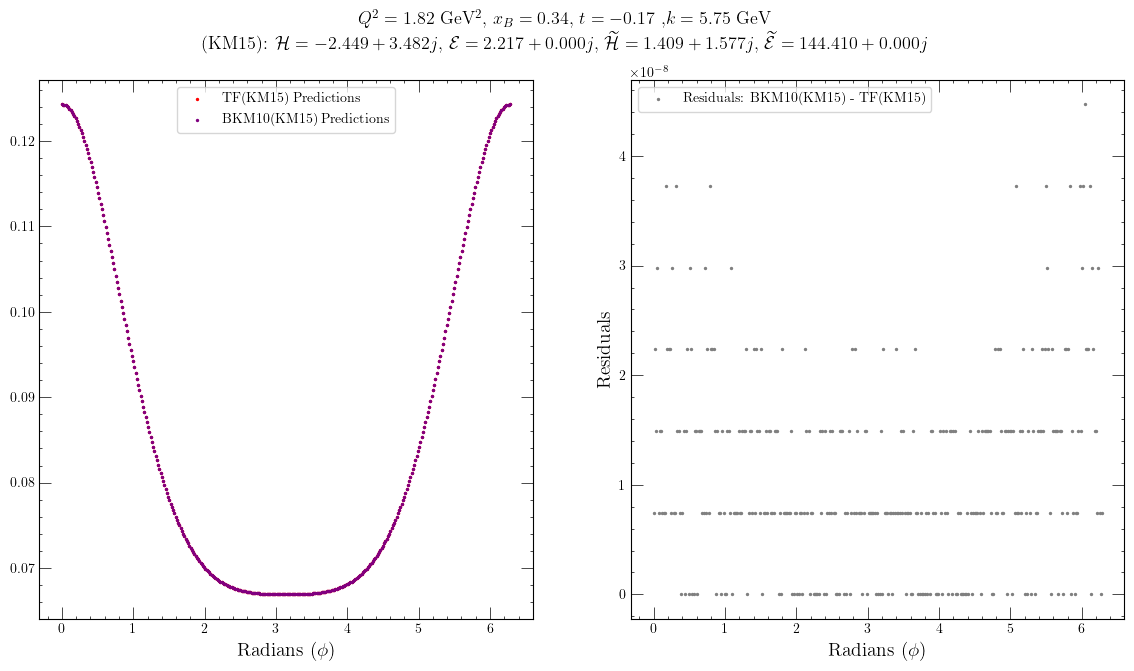

In [56]:
tf_cross_section_km15 = bkm10_cross_section(
    0.0, 0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_cross_section_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_cross_sections_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_cross_sections_km15 - tf_cross_section_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.2): Comparing $d^{4}\sigma^{UU}$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

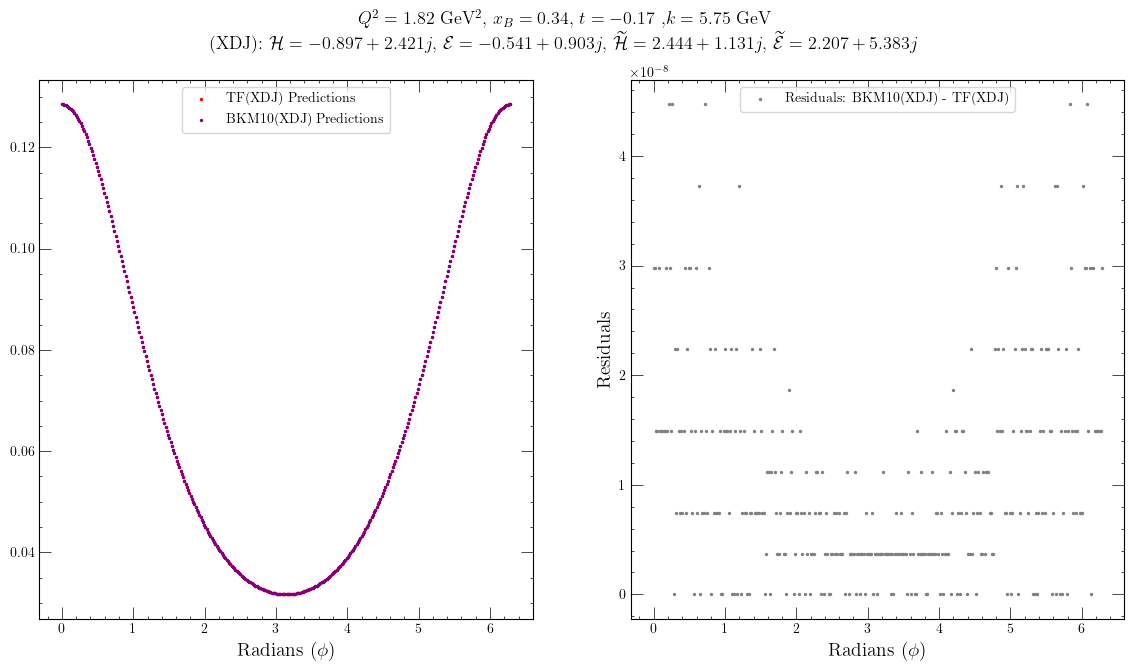

In [57]:
tf_cross_section_xdj = bkm10_cross_section(
    0.0, 0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_cross_section_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_cross_sections_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_cross_sections_xdj - tf_cross_section_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.3): Comparing $d^{4}\sigma^{+U}$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

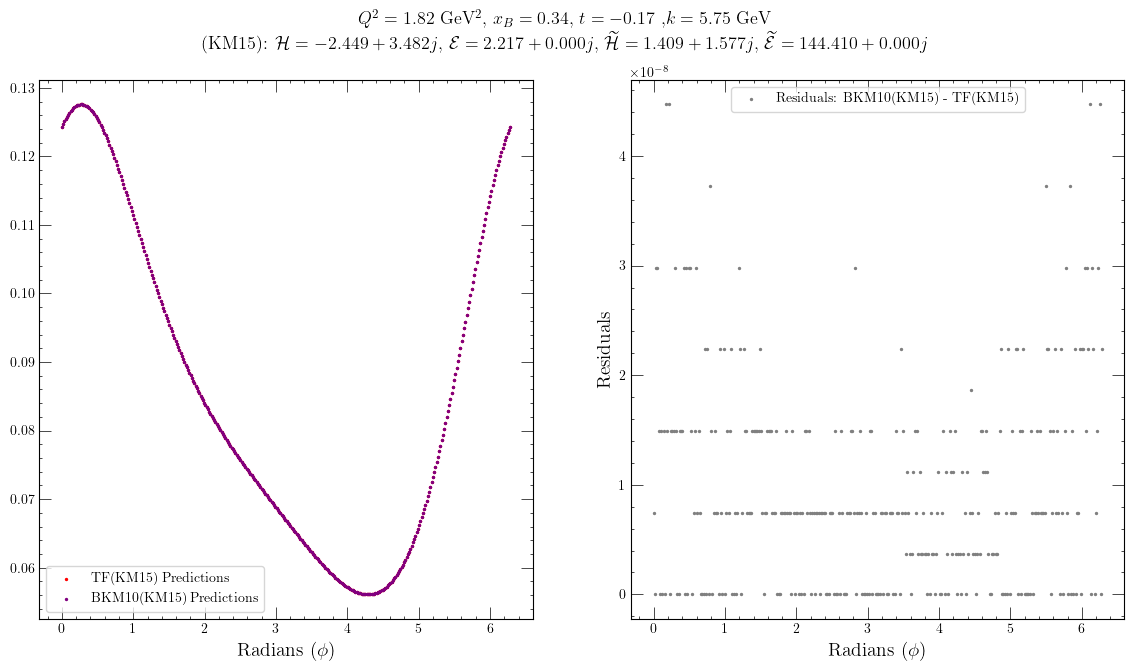

In [58]:
tf_plus_beam_unp_target_km15 = bkm10_cross_section(
    +1.0, 0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_beam_unp_target_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_beam_cross_sections_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_beam_cross_sections_km15 - tf_plus_beam_unp_target_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.4): Comparing $d^{4}\sigma^{+U}$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

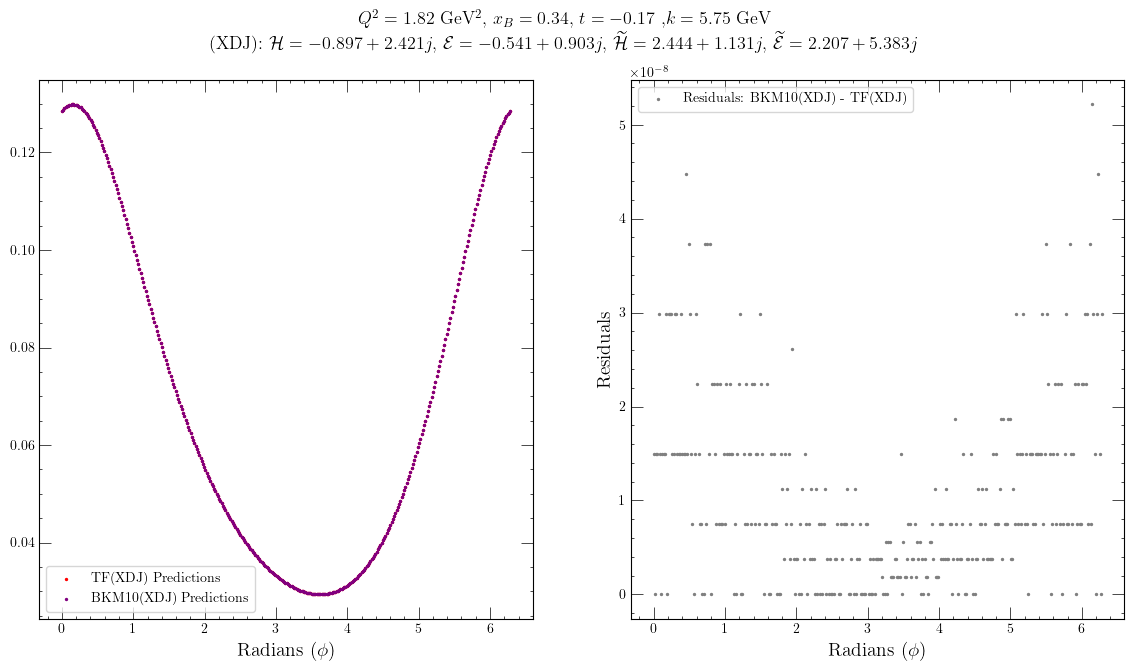

In [59]:
tf_plus_beam_unp_target_xdj = bkm10_cross_section(
    +1.0, 0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_beam_unp_target_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_beam_cross_sections_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_beam_cross_sections_xdj - tf_plus_beam_unp_target_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.5): Comparing $d^{4}\sigma^{-U}$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

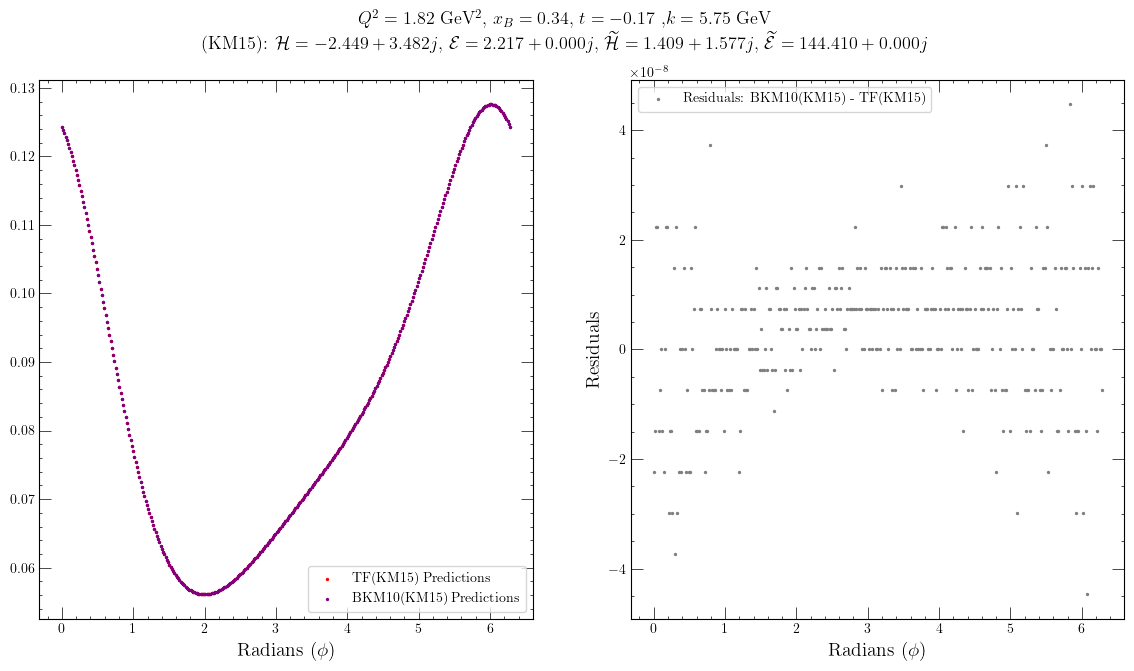

In [60]:
tf_minus_beam_unp_target_km15 = bkm10_cross_section(
    -1.0, 0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_beam_unp_target_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_beam_cross_sections_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, (bkm10_minus_beam_cross_sections_km15 - tf_minus_beam_unp_target_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.6): Comparing $d^{4}\sigma^{-U}$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

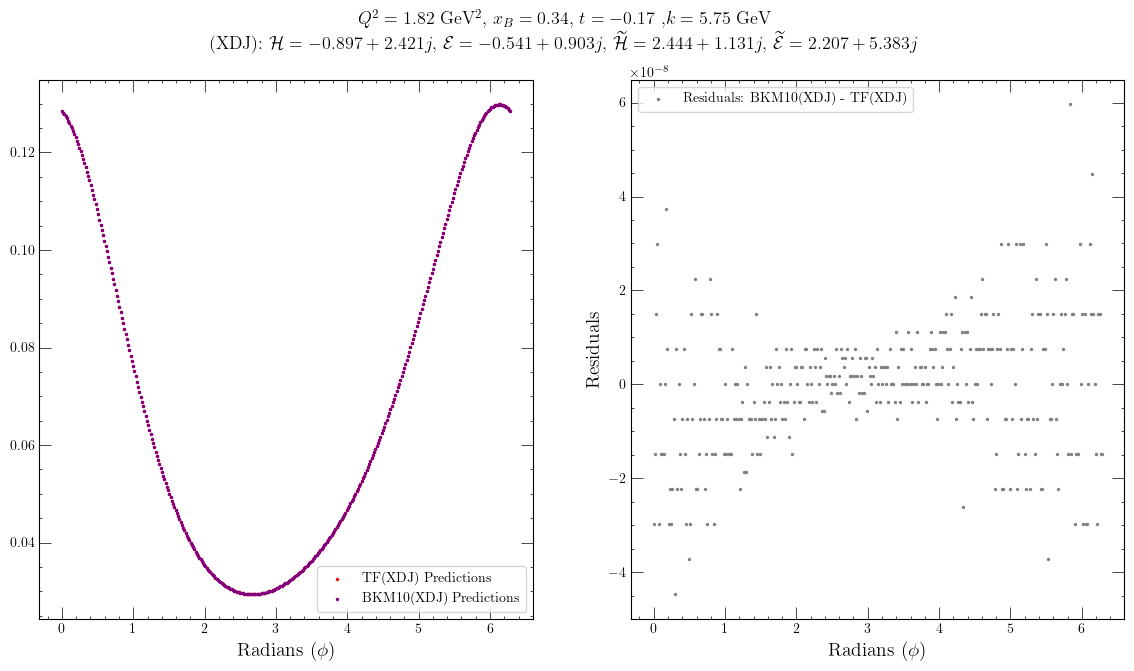

In [61]:
tf_minus_beam_unp_target_xdj = bkm10_cross_section(
    -1.0, 0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_beam_unp_target_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_beam_cross_sections_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, (bkm10_minus_beam_cross_sections_xdj - tf_minus_beam_unp_target_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.7): Comparing $d^{4}\sigma^{UL}$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

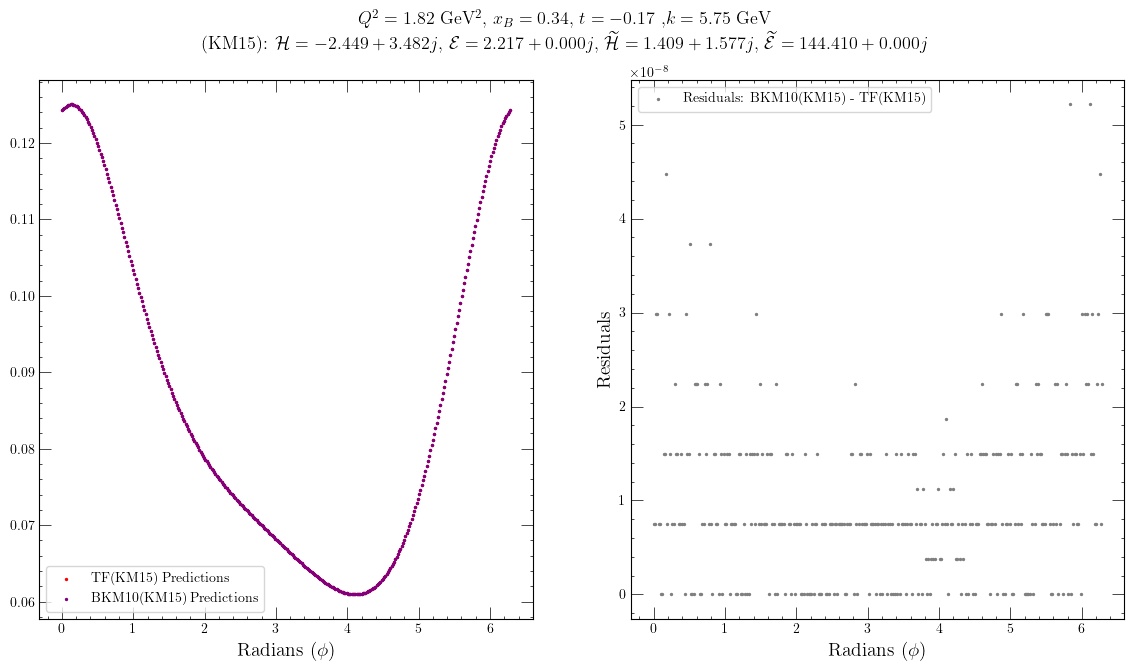

In [62]:
tf_lp_target_km15 = bkm10_cross_section(
    0.0, +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_lp_target_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_lp_cross_sections_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_lp_cross_sections_km15 - tf_lp_target_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.8): Comparing $d^{4}\sigma^{UL}$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

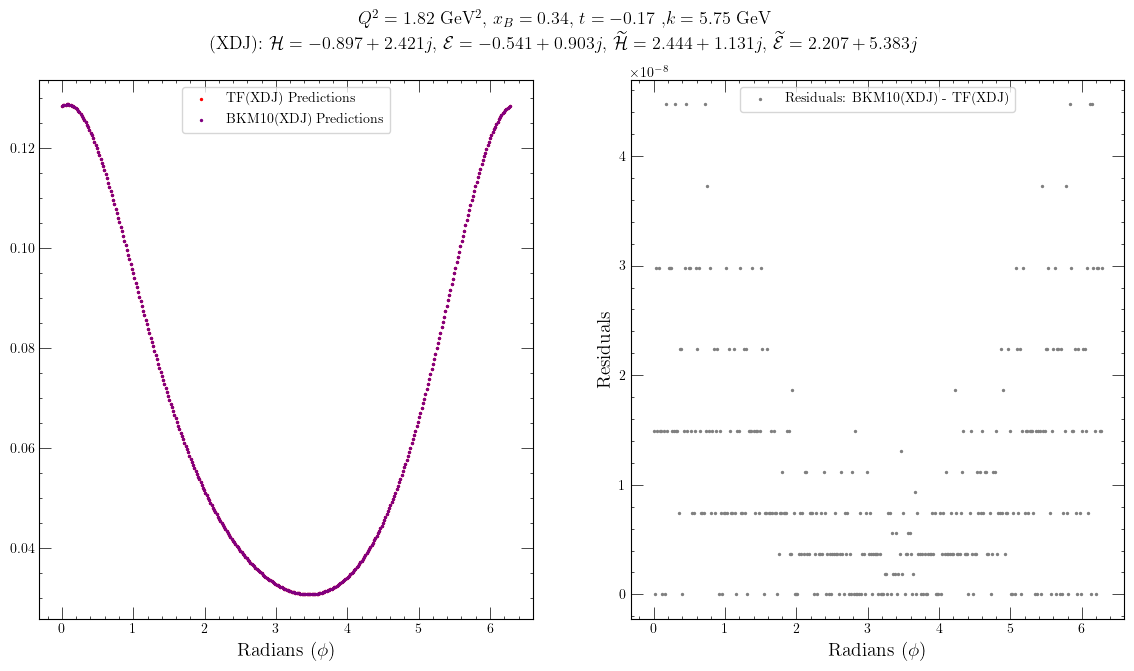

In [63]:
tf_lp_target_xdj = bkm10_cross_section(
    0.0, +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_lp_target_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_lp_cross_sections_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_lp_cross_sections_xdj - tf_lp_target_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.9): Comparing $d^{4}\sigma^{+L}$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

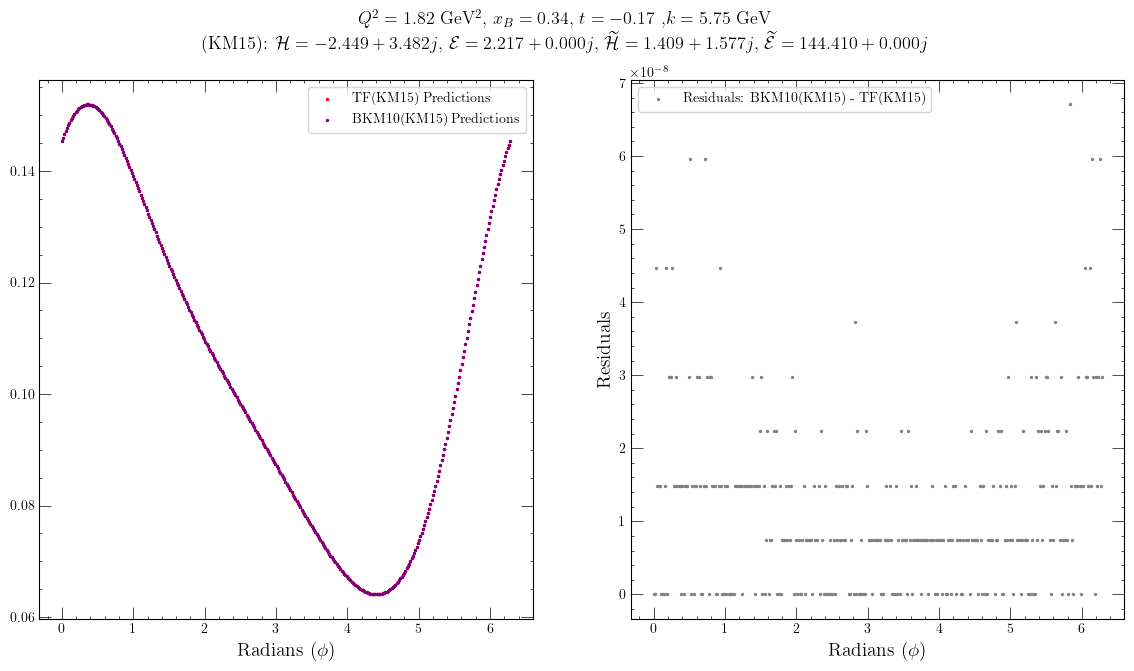

In [64]:
tf_plus_beam_lp_target_km15 = bkm10_cross_section(
    +1.0, +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_beam_lp_target_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_beam_lp_cross_sections_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_beam_lp_cross_sections_km15 - tf_plus_beam_lp_target_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.10): Comparing $d^{4}\sigma^{+L}$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

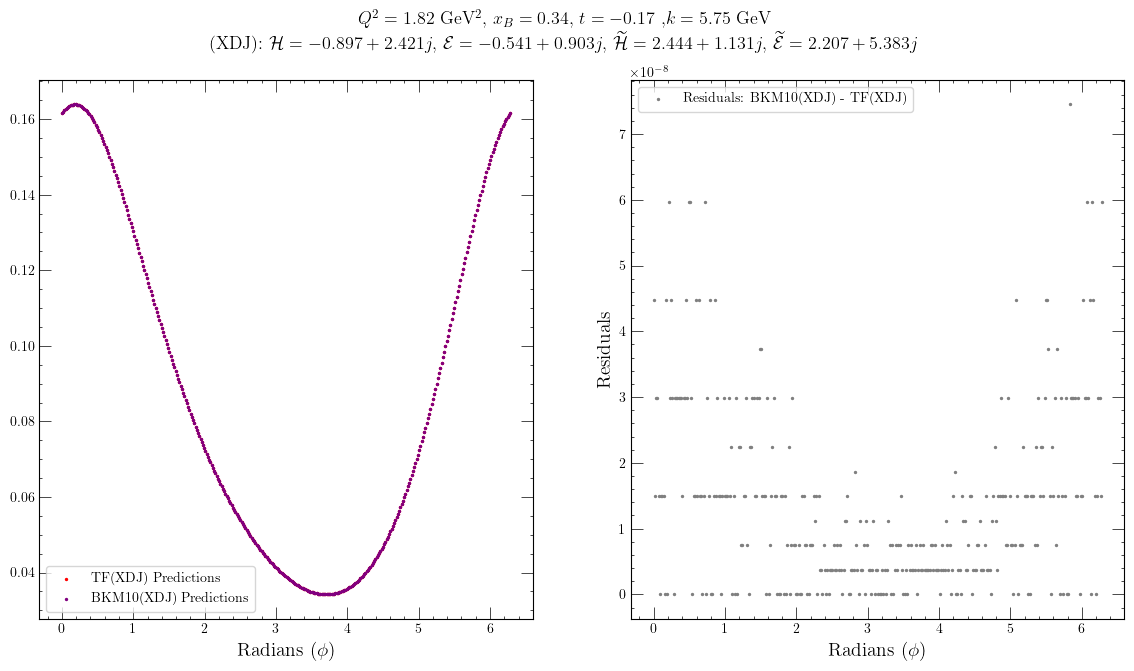

In [65]:
tf_plus_beam_lp_target_xdj = bkm10_cross_section(
    +1.0, +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_beam_lp_target_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_beam_lp_cross_sections_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_beam_lp_cross_sections_xdj - tf_plus_beam_lp_target_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.11): Comparing $d^{4}\sigma^{-L}$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

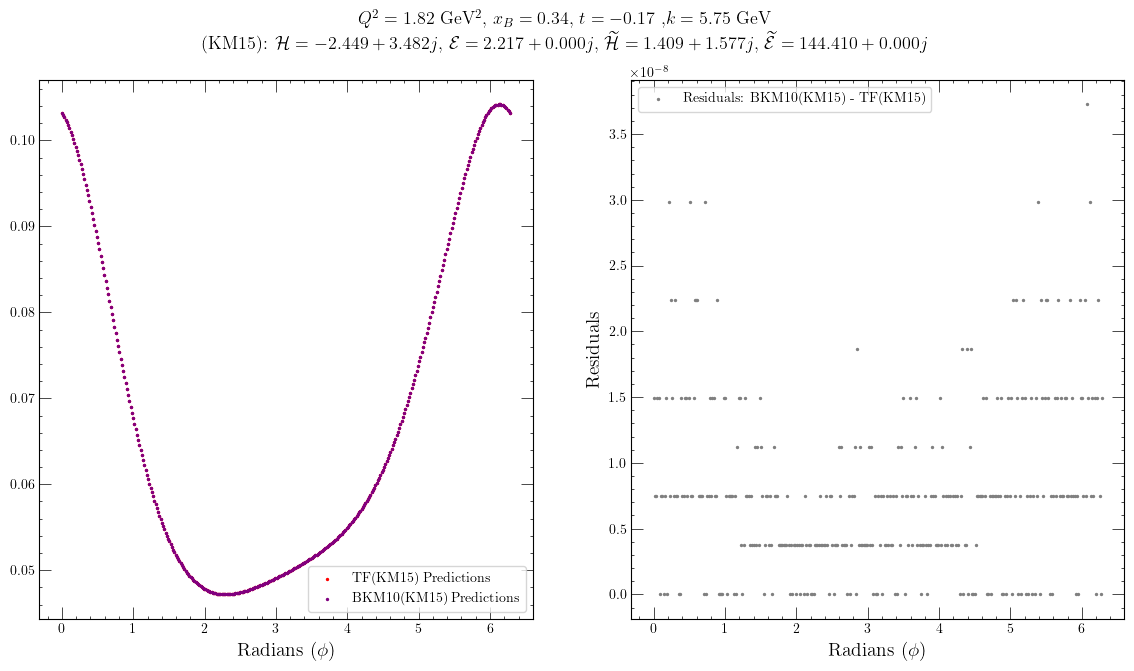

In [66]:
tf_minus_beam_lp_target_km15 = bkm10_cross_section(
    -1.0, +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_beam_lp_target_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_beam_lp_cross_sections_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_minus_beam_lp_cross_sections_km15 - tf_minus_beam_lp_target_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.12): Comparing $d^{4}\sigma^{-L}$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

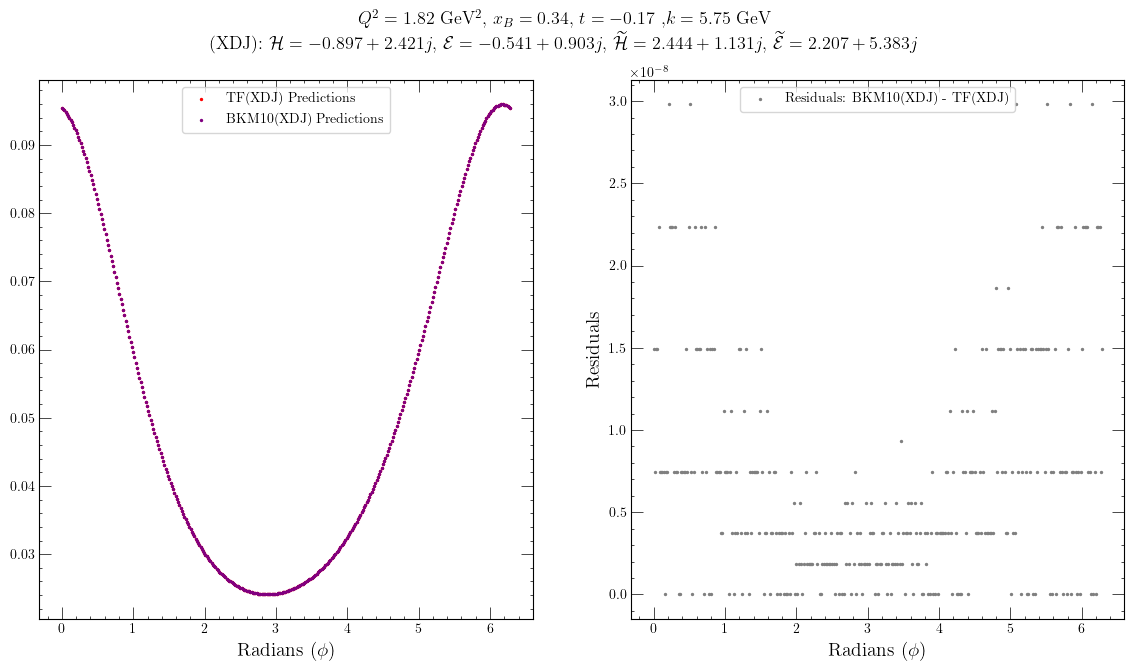

In [67]:
tf_minus_beam_lp_target_xdj = bkm10_cross_section(
    -1.0, +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_beam_lp_target_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_beam_lp_cross_sections_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_minus_beam_lp_cross_sections_xdj - tf_minus_beam_lp_target_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.13): Comparing $\text{BSA} \left( \Lambda = 0.0 \right)$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

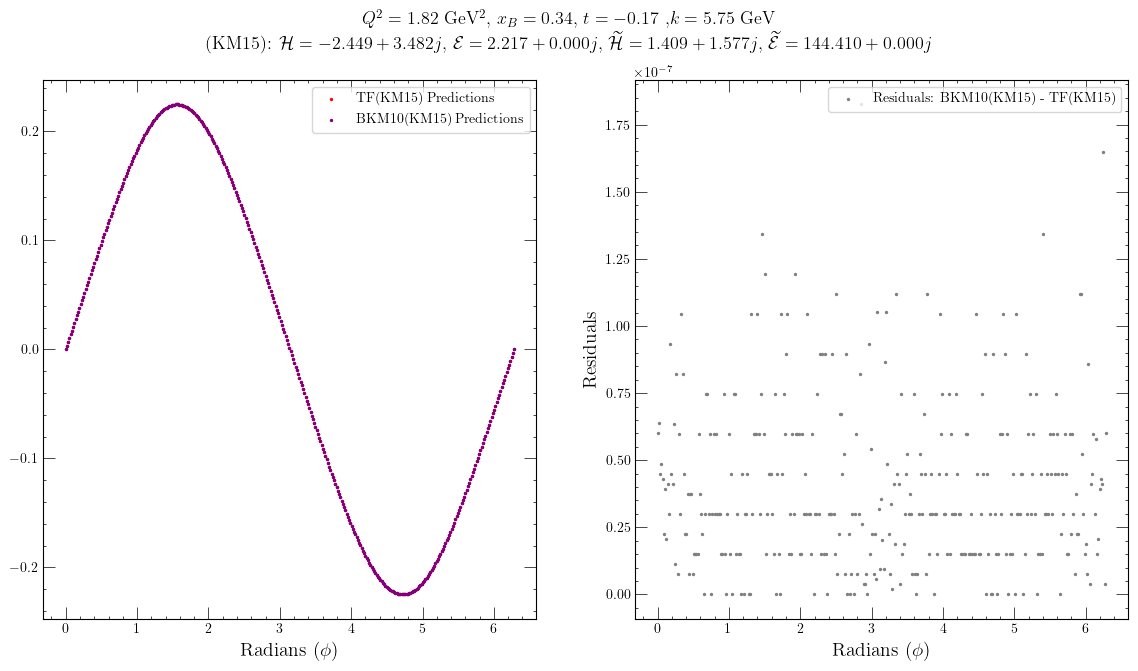

In [68]:
tf_unp_bsa_km15 = bkm10_bsa(
    0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_unp_bsa_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_bsa_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_bsa_km15 - tf_unp_bsa_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.14): Comparing $\text{BSA} \left( \Lambda = 0.0 \right)$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

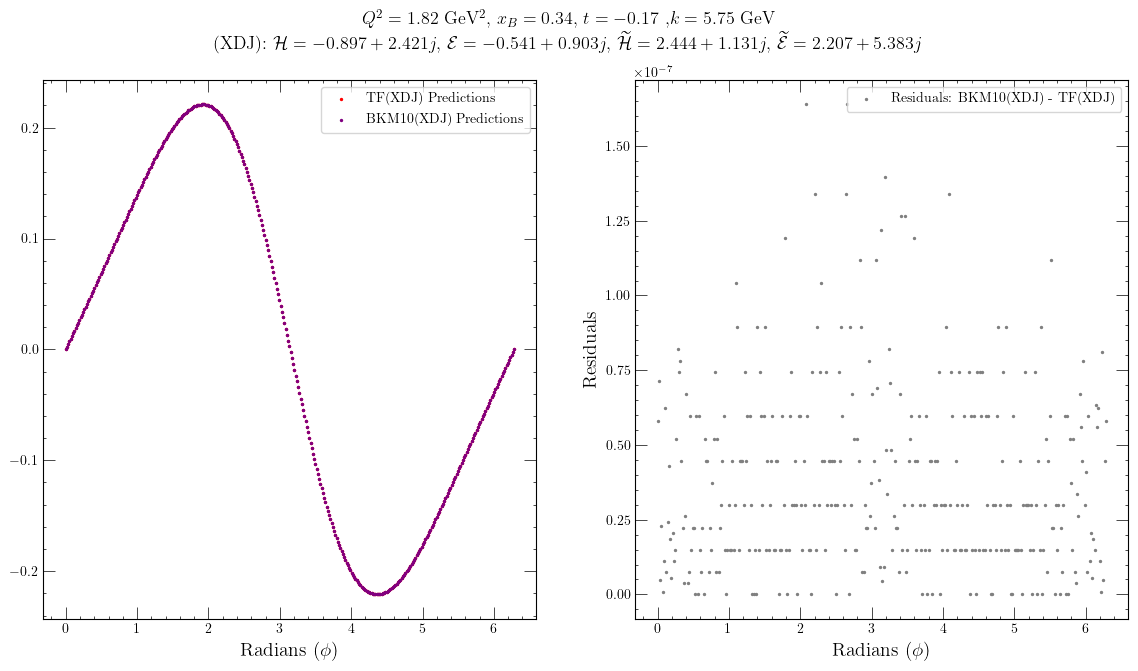

In [69]:
tf_unp_bsa_xdj = bkm10_bsa(
    0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_unp_bsa_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_bsa_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_bsa_xdj - tf_unp_bsa_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.15): Comparing $\text{BSA} \left( \Lambda = +1/2 \right)$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

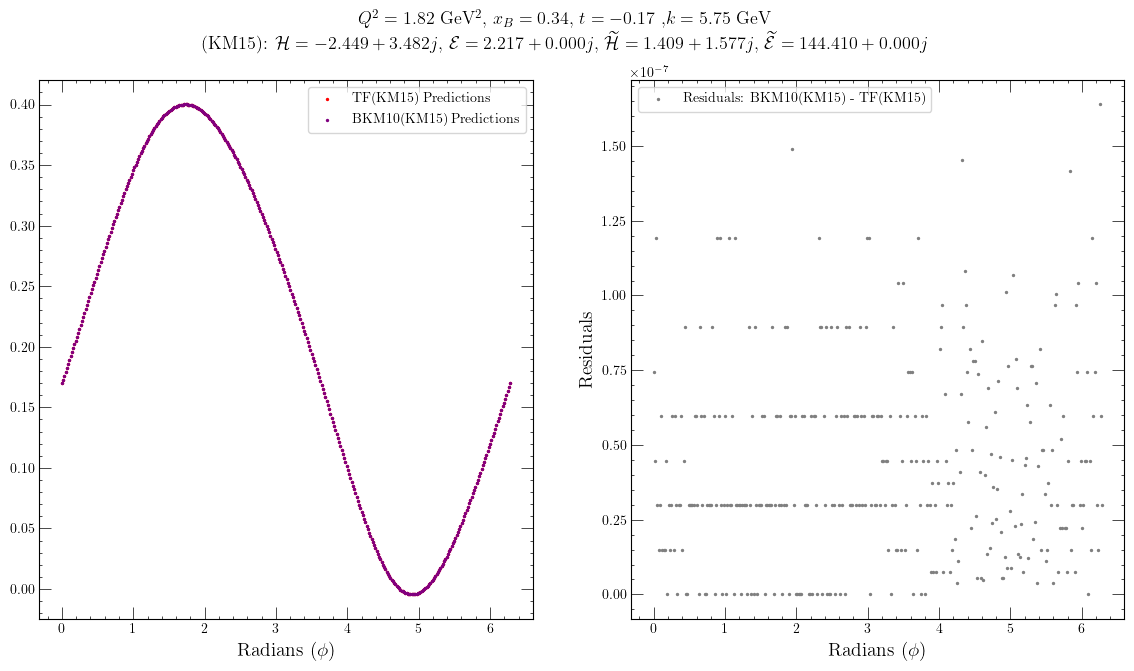

In [70]:
tf_plus_lp_bsa_km15 = bkm10_bsa(
    +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_lp_bsa_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_lp_bsa_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_lp_bsa_km15 - tf_plus_lp_bsa_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.15): Comparing $\text{BSA} \left( \Lambda = +1/2 \right)$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

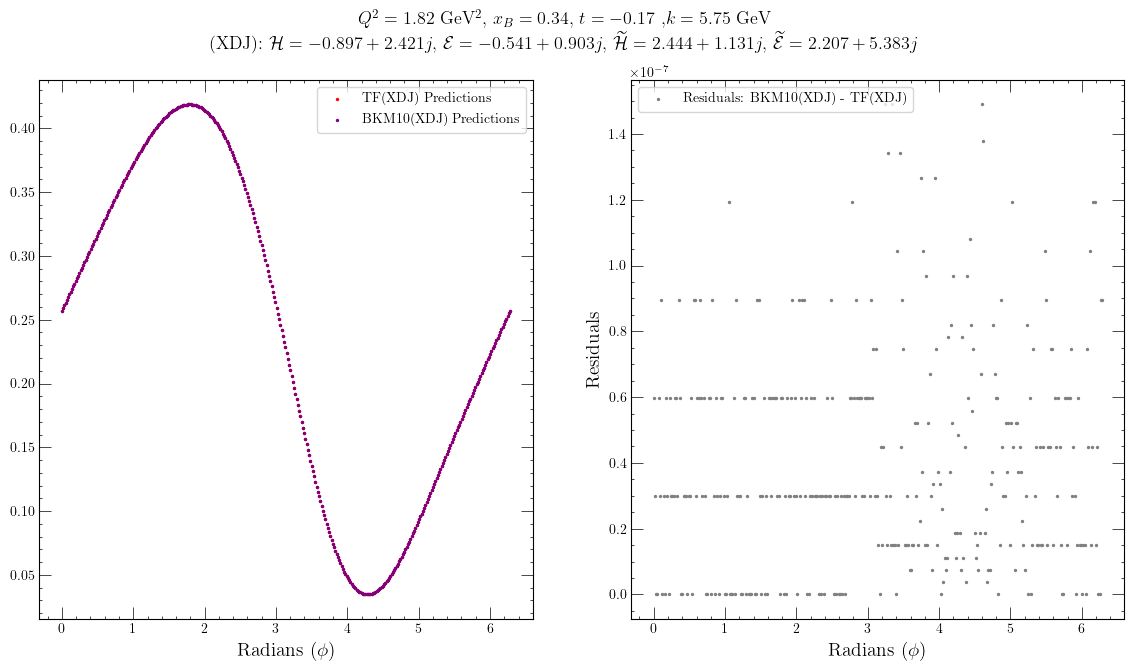

In [71]:
tf_plus_lp_bsa_xdj = bkm10_bsa(
    +0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_lp_bsa_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KXDJM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_lp_bsa_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_lp_bsa_xdj - tf_plus_lp_bsa_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.16): Comparing $\text{BSA} \left( \Lambda = -1/2 \right)$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

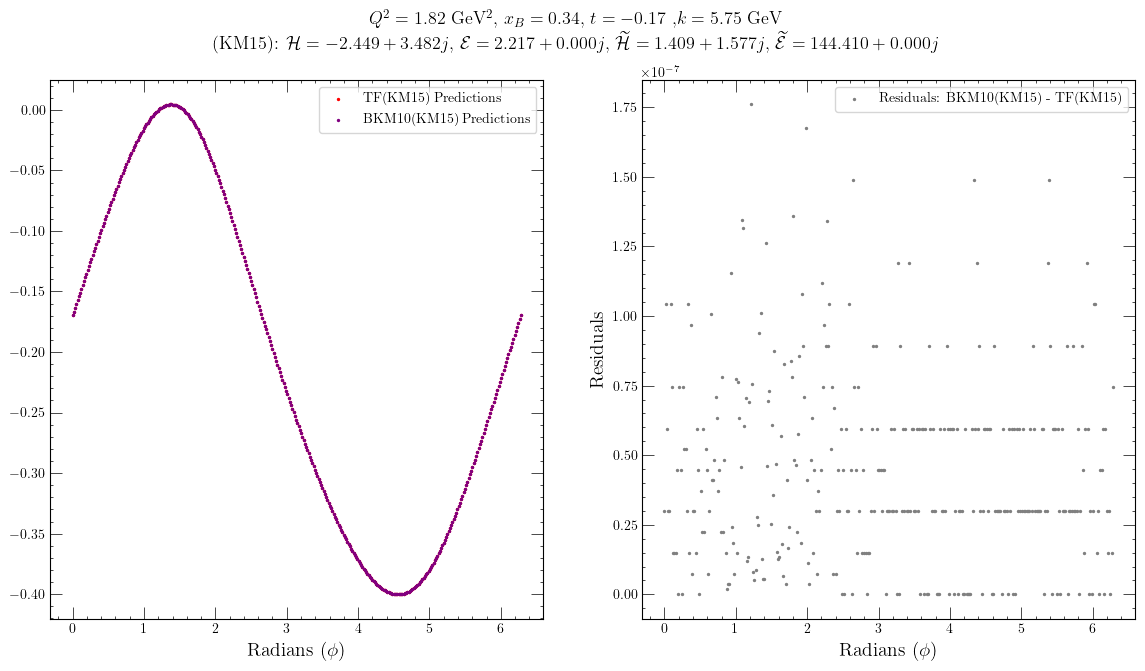

In [72]:
tf_minus_lp_bsa_km15 = bkm10_bsa(
    -0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_lp_bsa_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_lp_bsa_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_minus_lp_bsa_km15 - tf_minus_lp_bsa_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.17): Comparing $\text{BSA} \left( \Lambda = -1/2 \right)$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

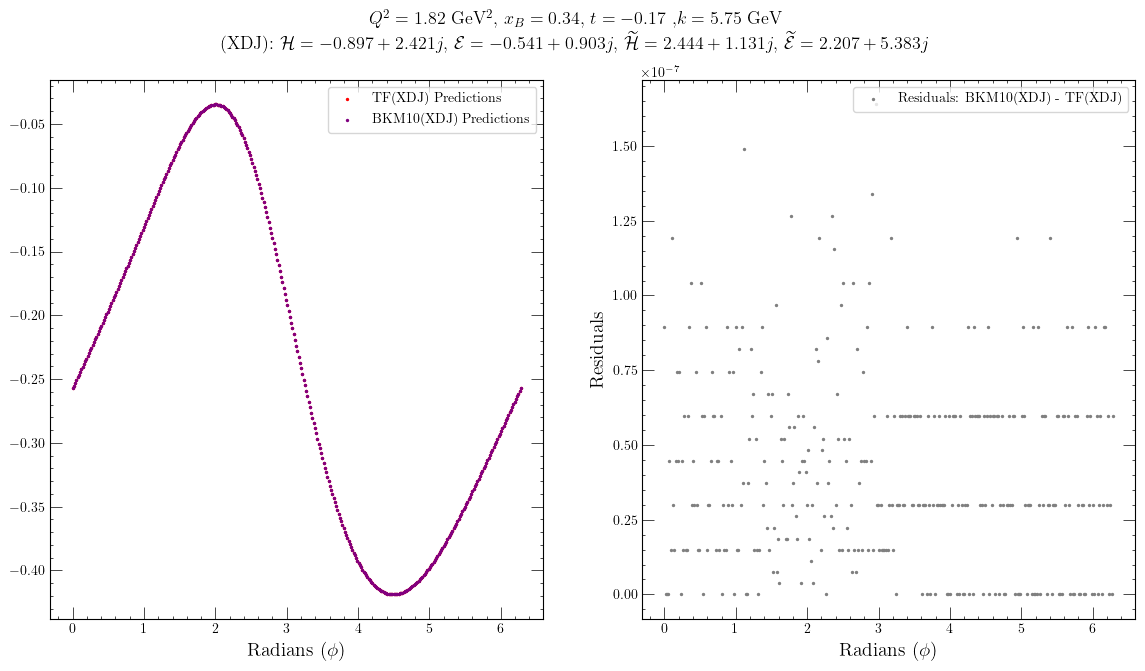

In [73]:
tf_minus_lp_bsa_xdj = bkm10_bsa(
    -0.5,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_lp_bsa_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_lp_bsa_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_minus_lp_bsa_xdj - tf_minus_lp_bsa_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.18): Comparing $\text{TSA} \left( \lambda = 0.0 \right)$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

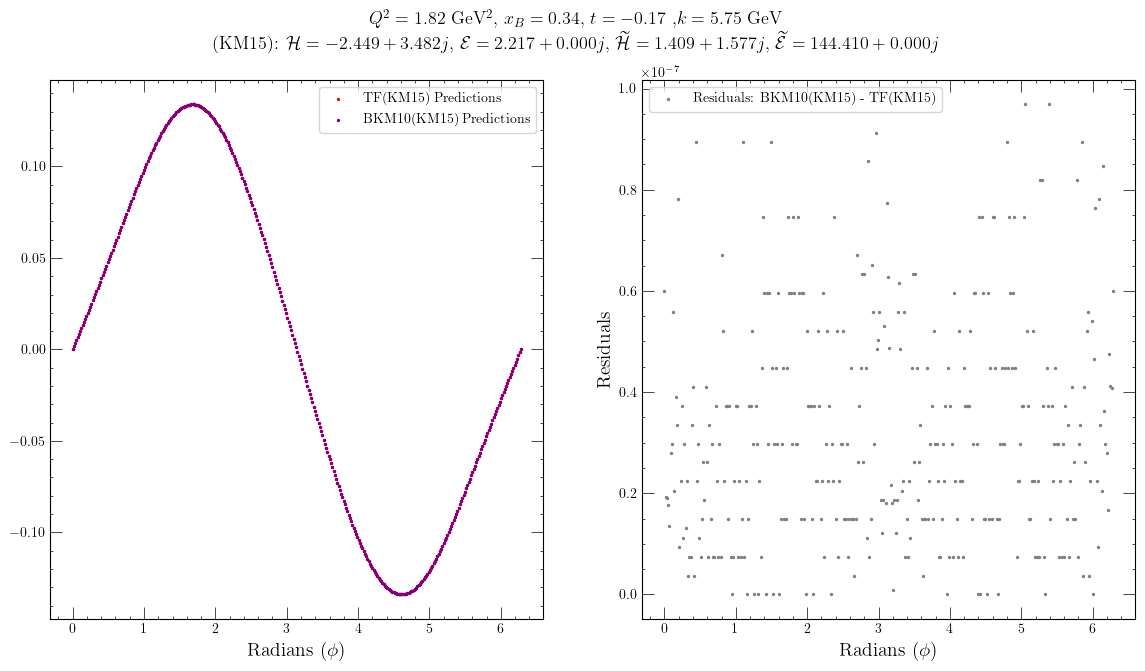

In [74]:
tf_tsa_km15 = bkm10_tsa(
    0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_tsa_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_tsa_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_tsa_km15 - tf_tsa_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.19): Comparing $\text{TSA} \left( \lambda = 0.0 \right)$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

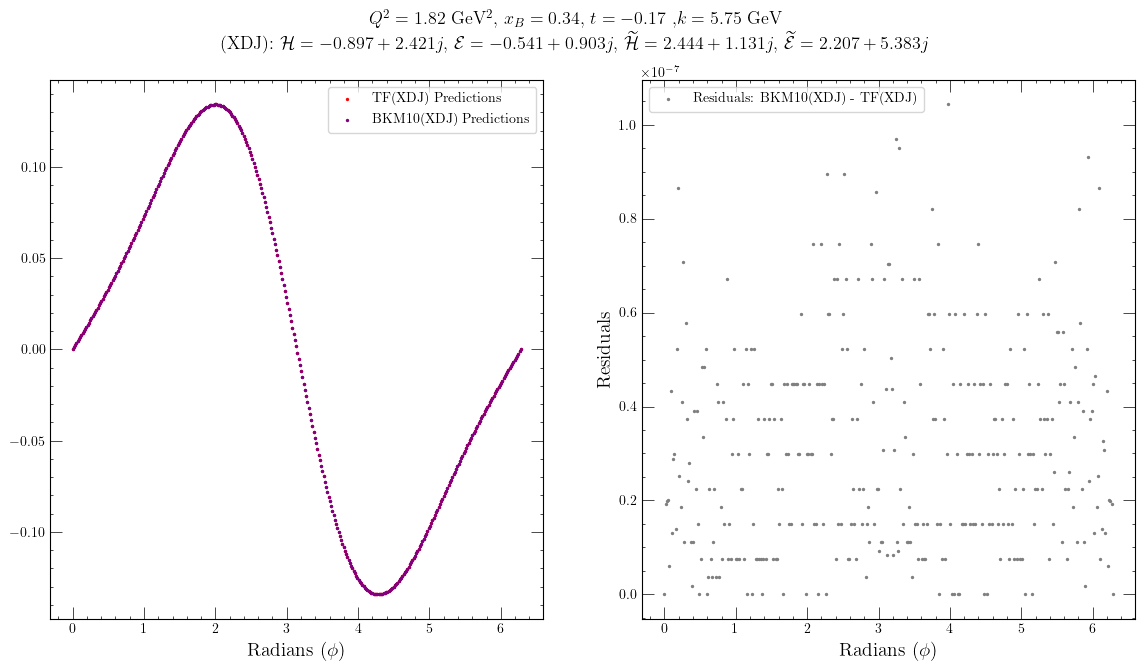

In [75]:
tf_tsa_xdj = bkm10_tsa(
    0.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_tsa_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_tsa_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_tsa_xdj - tf_tsa_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.20): Comparing $\text{TSA} \left( \lambda = +1 \right)$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

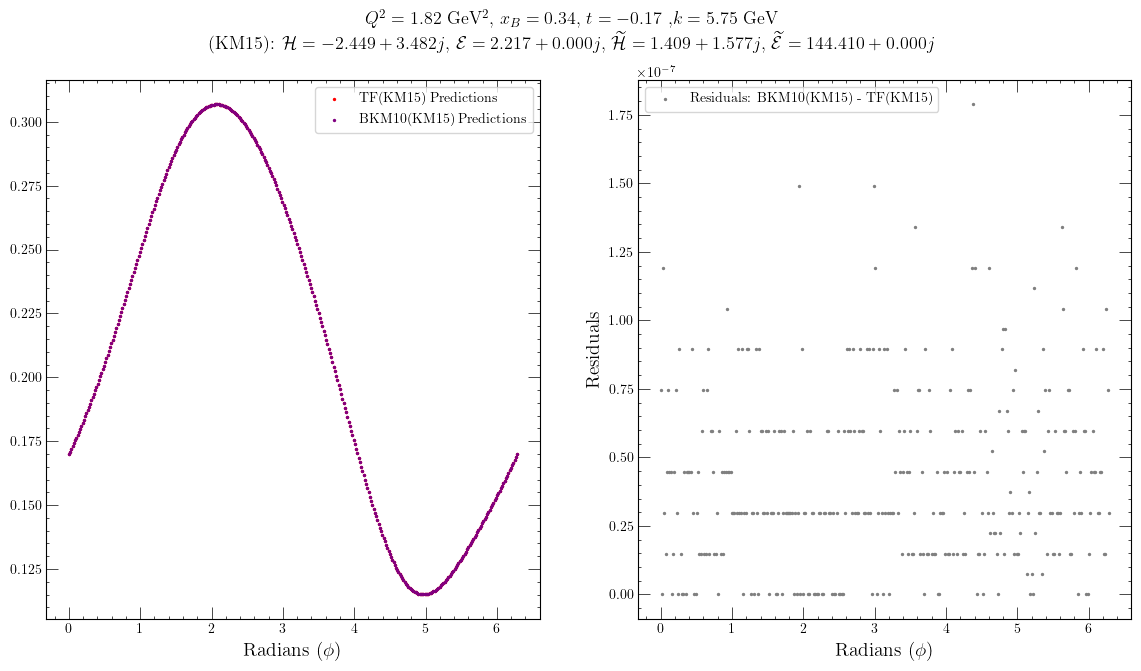

In [76]:
tf_plus_tsa_km15 = bkm10_tsa(
    +1.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_tsa_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_beam_tsa_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_beam_tsa_km15 - tf_plus_tsa_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.21): Comparing $\text{TSA} \left( \lambda = +1 \right)$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

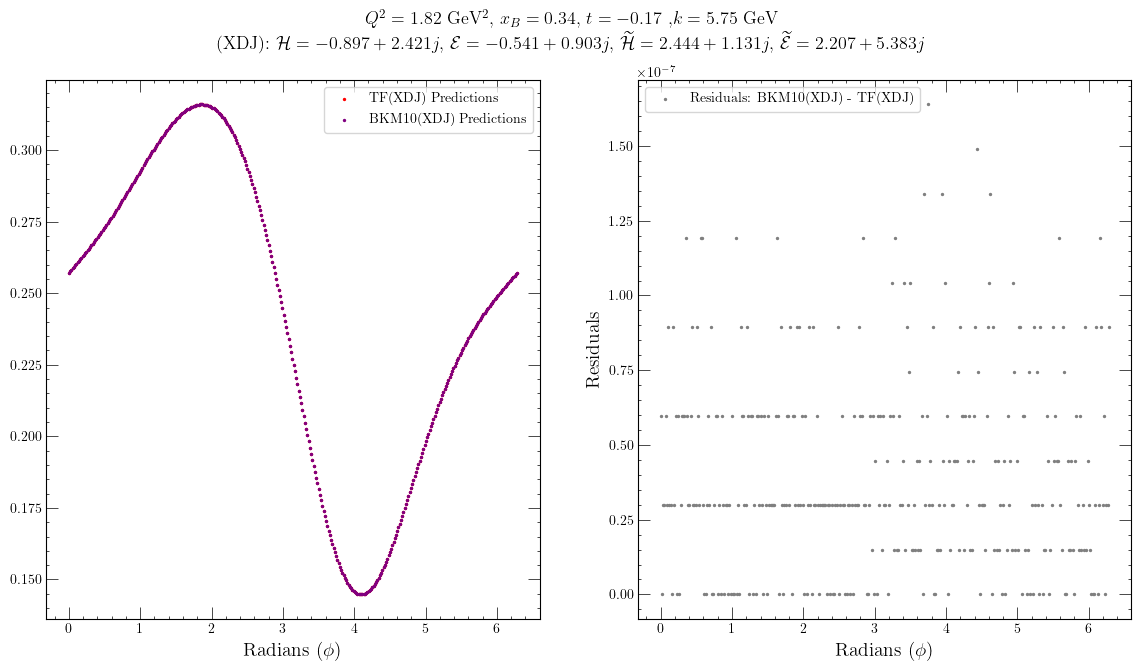

In [77]:
tf_plus_tsa_xdj = bkm10_tsa(
    +1.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_plus_tsa_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_plus_beam_tsa_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_plus_beam_tsa_xdj - tf_plus_tsa_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (3.3.22): Comparing $\text{TSA} \left( \lambda = -1 \right)$ (for KM15):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

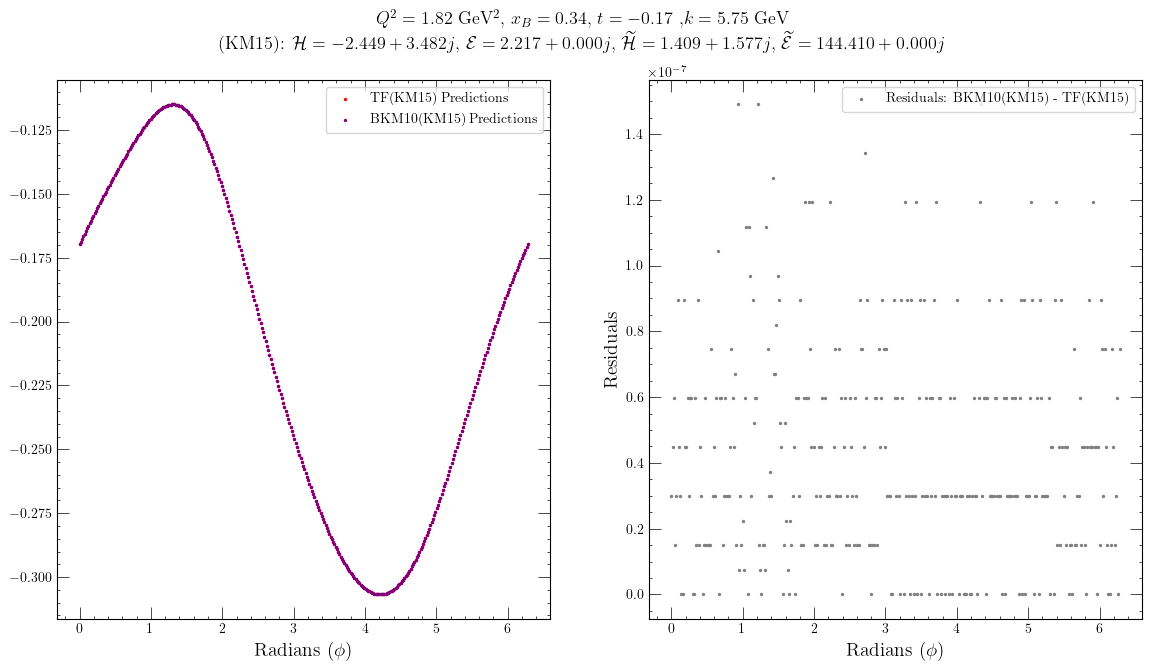

In [78]:
tf_minus_tsa_km15 = bkm10_tsa(
    -1.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15,
    CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_tsa_km15, 
    color = "red", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_beam_tsa_km15, 
    color = "purple", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_minus_beam_tsa_km15 - tf_minus_tsa_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)

#### (3.3.23): Comparing $\text{TSA} \left( \lambda = -1 \right)$ (for XDJ):

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

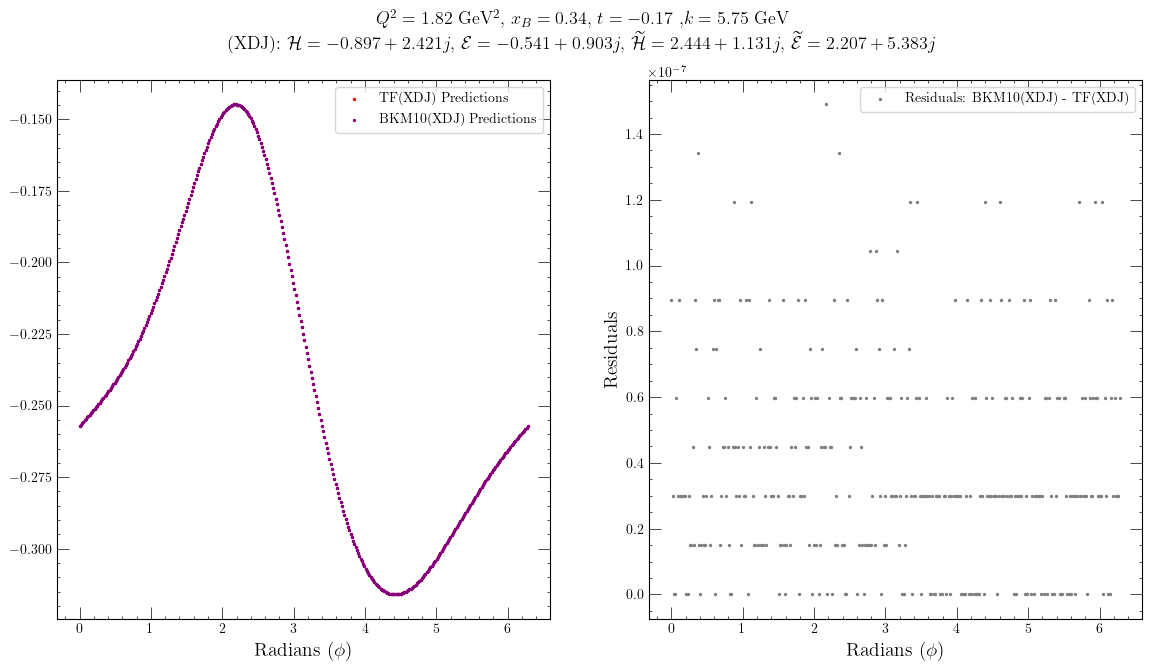

In [79]:
tf_minus_tsa_xdj = bkm10_tsa(
    -1.0,
    TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y,
    TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians,
    TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ,
    CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 2, figsize = (14, 7))

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, tf_minus_tsa_xdj, 
    color = "red", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(XDJ))
xsec_test_ax[0].scatter(
    phi_array_in_radians, bkm10_minus_beam_tsa_xdj, 
    color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# residuals
xsec_test_ax[1].scatter(
    phi_array_in_radians, np.abs(bkm10_minus_beam_tsa_xdj - tf_minus_tsa_xdj),
    color = "gray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
)

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_ylabel(r"Residuals", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

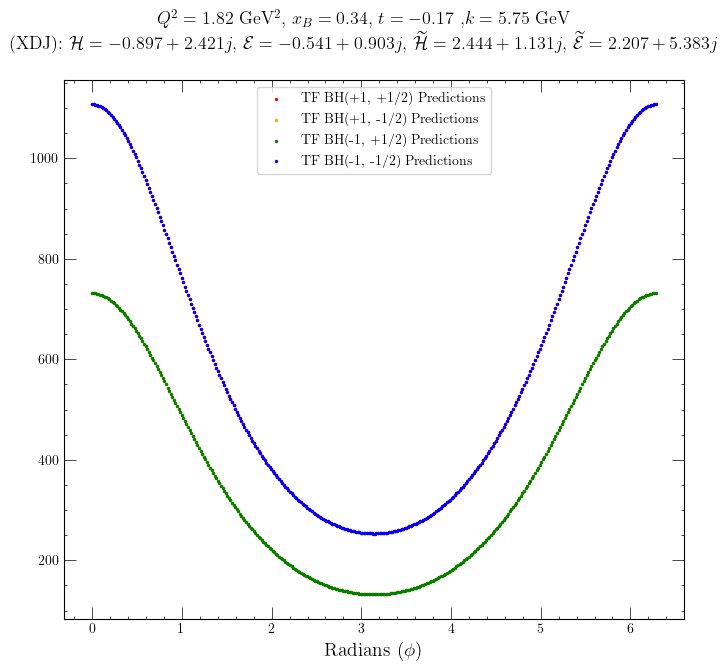

In [80]:
bh_plus_beam_plus_target = bh_squared(+1.0, +0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)
bh_plus_beam_minus_target = bh_squared(+1.0, -0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)
bh_minus_beam_plus_target = bh_squared(-1.0, +0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)
bh_minus_beam_minus_target = bh_squared(-1.0, -0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 1, figsize = (8, 7))

xsec_test_ax.scatter(
    phi_array_in_radians, bh_plus_beam_plus_target, 
    color = "red", s = 2., label = "TF BH(+1, +1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, bh_plus_beam_minus_target, 
    color = "orange", s = 2., label = "TF BH(+1, -1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, bh_minus_beam_plus_target, 
    color = "green", s = 2., label = "TF BH(-1, +1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, bh_minus_beam_minus_target, 
    color = "blue", s = 2., label = "TF BH(-1, -1/2) Predictions")

xsec_test_ax.set_xlabel(r"Radians ($\phi$)", fontsize = 14)

xsec_test_ax.legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

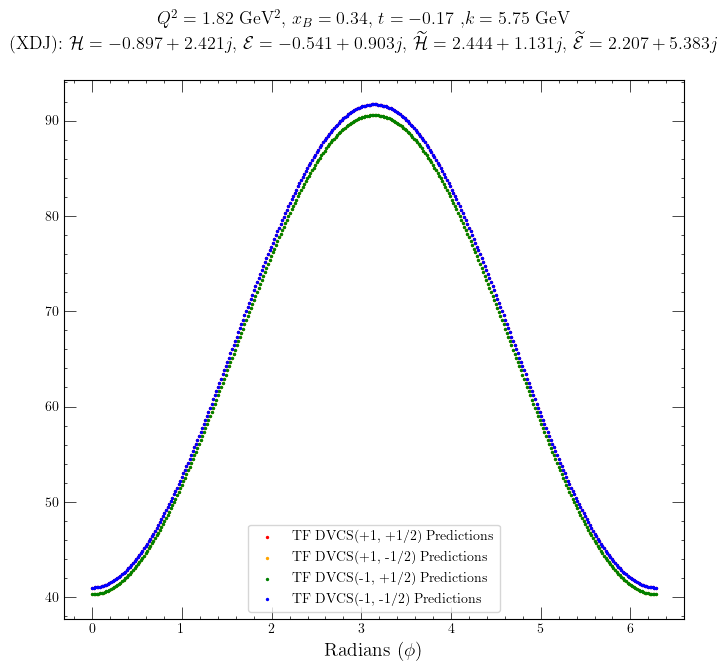

In [81]:
dvcs_plus_beam_plus_target = dvcs_squared(
    +1.0, +0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)
dvcs_plus_beam_minus_target = dvcs_squared(
    +1.0, -0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)
dvcs_minus_beam_plus_target = dvcs_squared(
    -1.0, +0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)
dvcs_minus_beam_minus_target = dvcs_squared(
    -1.0, -0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 1, figsize = (8, 7))

xsec_test_ax.scatter(
    phi_array_in_radians, dvcs_plus_beam_plus_target, 
    color = "red", s = 2., label = "TF DVCS(+1, +1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, dvcs_plus_beam_minus_target, 
    color = "orange", s = 2., label = "TF DVCS(+1, -1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, dvcs_minus_beam_plus_target, 
    color = "green", s = 2., label = "TF DVCS(-1, +1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, dvcs_minus_beam_minus_target, 
    color = "blue", s = 2., label = "TF DVCS(-1, -1/2) Predictions")

xsec_test_ax.set_xlabel(r"Radians ($\phi$)", fontsize = 14)

xsec_test_ax.legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(XDJ): $\\mathcal{H} = -0.897+2.421j$, $\\mathcal{E} = -0.541+0.903j$, $\\widetilde{\\mathcal{H}} = 2.444+1.131j$, $\\widetilde{\\mathcal{E}} = 2.207+5.383j$ ')

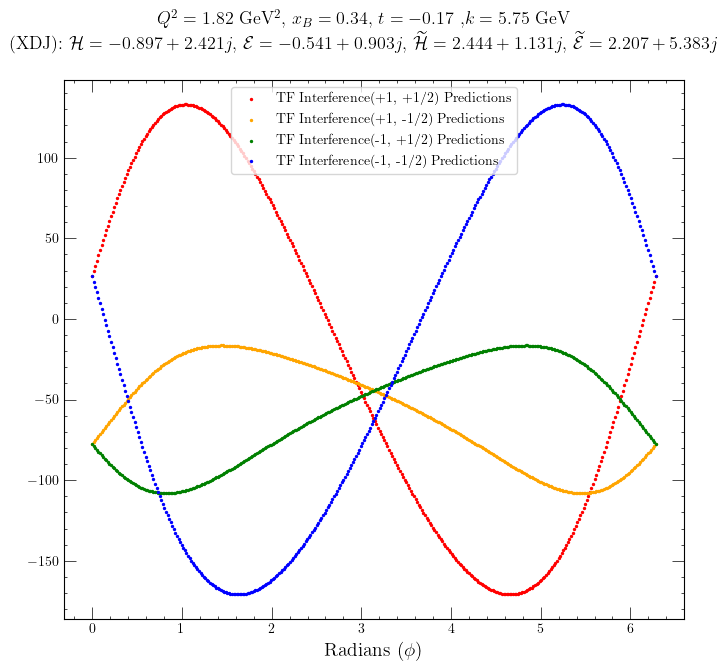

In [82]:
interference_plus_beam_plus_target = interference_amplitude(
    +1.0, +0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)
interference_plus_beam_minus_target = interference_amplitude(
    +1.0, -0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)
interference_minus_beam_plus_target = interference_amplitude(
    -1.0, +0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)
interference_minus_beam_minus_target = interference_amplitude(
    -1.0, -0.5, TEST_QSQ, TEST_XB, TEST_T, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    CFF_REAL_H_XDJ, CFF_REAL_HT_XDJ, CFF_REAL_E_XDJ, CFF_REAL_ET_XDJ, CFF_IMAG_H_XDJ, CFF_IMAG_HT_XDJ, CFF_IMAG_E_XDJ, CFF_IMAG_ET_XDJ, True)

xsec_test_fig, xsec_test_ax = plt.subplots(1, 1, figsize = (8, 7))

xsec_test_ax.scatter(
    phi_array_in_radians, interference_plus_beam_plus_target, 
    color = "red", s = 2., label = "TF Interference(+1, +1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, interference_plus_beam_minus_target, 
    color = "orange", s = 2., label = "TF Interference(+1, -1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, interference_minus_beam_plus_target, 
    color = "green", s = 2., label = "TF Interference(-1, +1/2) Predictions")
xsec_test_ax.scatter(
    phi_array_in_radians, interference_minus_beam_minus_target, 
    color = "blue", s = 2., label = "TF Interference(-1, -1/2) Predictions")

xsec_test_ax.set_xlabel(r"Radians ($\phi$)", fontsize = 14)

xsec_test_ax.legend()

xsec_test_fig.suptitle(f"{title_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)